In [ ]:
%load_ext autoreload
%autoreload 2

In [103]:
import contextlib
from os import path, makedirs
from datetime import datetime
from functools import partial

import numpy as np
import pandas as pd

import sys
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana')
from pyanalib.split_df_helpers import load_dfs
from pyanalib.split_df_helpers_new import dfs_from_dir
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
plt.style.use("presentation.mplstyle")

In [3]:
DFS_ROOT = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs"
DIR_DATA = path.join(DFS_ROOT, "2026_05_16_230759__sel_2prong-data-1e20")
# QUALITY_DF_PATH = path.join(QUALITY_DF_DIR, "beam_data_1e20_qualitycut.df")

DIR_MC = path.join(DFS_ROOT, "2026_05_06_073032__sel_2prong-mc-BNB_cosmics")
DIR_INTIME = path.join(DFS_ROOT, "2026_05_05_193232__sel_2prong-mc-Intime")
DIR_OFFBEAM = path.join(DFS_ROOT, "2026_05_05_233424__sel_2prong-data-OffBeamLight")
DIR_DIRT = path.join(DFS_ROOT, "2026_05_06_135816__sel_2prong-mc-dirt")

KEYS2LOAD = ["hdr", "evt"]
N_MAX_CONCAT = 999

FOM_CUT = 0.98
MIN_RUN_DURATION_MIN = 20.0

save_fig = True
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(
    save_fig_base_dir,
    f"data_mc_chi2_comparison_{today_str}",
)
# print("quality-cut df:", QUALITY_DF_PATH)
print("saving plots in", save_fig_dir)

saving plots in /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260602


In [4]:
from pyanalib.split_df_helpers_new import dfs_from_dir

mc_dfs = dfs_from_dir(
    DIR_MC,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
intime_dfs = dfs_from_dir(
    DIR_INTIME,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
offbeam_dfs = dfs_from_dir(
    DIR_OFFBEAM,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
dirt_dfs = dfs_from_dir(
    DIR_DIRT,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
data_dfs = dfs_from_dir(
    DIR_DATA,
    filename_str="sel_2prong",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)

mc_evt_df = mc_dfs["evt"]
mc_hdr_df = mc_dfs["hdr"]

intime_evt_df = intime_dfs["evt"]
intime_hdr_df = intime_dfs["hdr"]

offbeam_evt_df = offbeam_dfs["evt"]
offbeam_hdr_df = offbeam_dfs["hdr"]

dirt_evt_df = dirt_dfs["evt"]
dirt_hdr_df = dirt_dfs["hdr"]

data_evt_df = data_dfs["evt"]
data_hdr_df = data_dfs["hdr"]

print(f"mc:      evt={len(mc_evt_df):,}  hdr={len(mc_hdr_df):,}")
print(f"intime:  evt={len(intime_evt_df):,}  hdr={len(intime_hdr_df):,}")
print(f"offbeam: evt={len(offbeam_evt_df):,}  hdr={len(offbeam_hdr_df):,}")
print(f"dirt:    evt={len(dirt_evt_df):,}  hdr={len(dirt_hdr_df):,}")
print(f"data:    evt={len(data_evt_df):,}  hdr={len(data_hdr_df):,}")

mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999
dirt_evt_df.loc[dirt_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999

data_evt_df[("mc", "iscc")] = 999
print(f"evt_good rows: {len(data_evt_df):,}")

Found 999 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1001.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_06_073032__sel_2prong-mc-BNB_cosmics/sel_2prong-mc-BNB_cosmics_1002.df', '/pnfs/sbnd/scratch/users/munjung/cafpy

100%|██████████| 999/999 [08:55<00:00,  1.86it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 200 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232__sel_2prong-mc-Intime/sel_2prong-mc-Intime_103.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_193232_

100%|██████████| 200/200 [01:39<00:00,  2.01it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 200 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamLight/sel_2prong-data-OffBeamLight_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_05_233424__sel_2prong-data-OffBeamL

...

100%|██████████| 500/500 [03:02<00:00,  2.74it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 100 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_0.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_1.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_11.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_12.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_13.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel_2prong-data-1e20/sel_2prong-data-1e20_14.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230759__sel

100%|██████████| 100/100 [01:02<00:00,  1.61it/s]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
mc:      evt=725,456  hdr=3,187,761
intime:  evt=159,230  hdr=2,149,555
offbeam: evt=170,151  hdr=1,655,098
dirt:    evt=110,336  hdr=1,631,640
data:    evt=342,761  hdr=1,773,921
evt_good rows: 342,761


/tmp/ipykernel_2143107/3331057512.py:55: PerformanceWarning: indexing past lexsort depth may impact performance.
  mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999
/tmp/ipykernel_2143107/3331057512.py:56: PerformanceWarning: indexing past lexsort depth may impact performance.
  dirt_evt_df.loc[dirt_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999
/tmp/ipykernel_2143107/3331057512.py:58: PerformanceWarning: indexing past lexsort depth may impact performance.
  data_evt_df[("mc", "iscc")] = 999


In [67]:
data_tot_pot = data_hdr_df["pot"].sum()
data_gates = data_hdr_df.nbnbinfo.sum()


pot_str = get_pot_str(data_tot_pot)
pot_label = f"Events / Bin (POT={pot_str})"

data_evt_df["pot_weight"] = np.ones(len(data_evt_df))

mc_tot_pot = mc_hdr_df["pot"].sum()
mc_pot_scale = data_tot_pot / mc_tot_pot
print(f"mc_pot_scale: {mc_pot_scale:.3e}")
mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))

dirt_tot_pot = dirt_hdr_df["pot"].sum()
dirt_pot_scale = data_tot_pot / dirt_tot_pot
print(f"dirt_pot_scale: {dirt_pot_scale:.3e}")
dirt_evt_df["pot_weight"] = dirt_pot_scale * np.ones(len(dirt_evt_df))

intime_gates = intime_hdr_df[intime_hdr_df["first_in_subrun"] == 1]["ngenevt"].sum()
f = 0.08
scale_intime_to_lightdata = (1 - f) * data_gates / intime_gates
print(f"intime data scale: {scale_intime_to_lightdata:.2f}")
intime_evt_df["pot_weight"] = scale_intime_to_lightdata * np.ones(len(intime_evt_df))

offbeam_gates = offbeam_hdr_df[offbeam_hdr_df["first_in_subrun"] == 1]["noffbeambnb"].sum()
f = 0.08
scale_offbeam_to_lightdata = (1 - f) * data_gates / offbeam_gates
print(f"offbeam data scale: {scale_offbeam_to_lightdata:.2f}")
offbeam_evt_df["pot_weight"] = scale_offbeam_to_lightdata * np.ones(len(offbeam_evt_df))

mc_pot_scale: 3.190e-01
dirt_pot_scale: 2.422e-01
intime data scale: 0.17
offbeam data scale: 0.22


In [85]:
for df in (mc_evt_df, data_evt_df, intime_evt_df, dirt_evt_df, offbeam_evt_df):
    df[("trk1", "pfp", "trk", "phi", "", "", "")] = np.degrees(
        np.arctan2(
            df[("trk1", "pfp", "trk", "dir", "x", "", "")],
            df[("trk1", "pfp", "trk", "dir", "y", "", "")],
        )
    )
    df[("trk2", "pfp", "trk", "phi", "", "", "")] = np.degrees(
        np.arctan2(
            df[("trk2", "pfp", "trk", "dir", "x", "", "")],
            df[("trk2", "pfp", "trk", "dir", "y", "", "")],
        )
    )

In [86]:
for df in (mc_evt_df, data_evt_df, intime_evt_df, dirt_evt_df, offbeam_evt_df):
    # Get direction vectors for trk1 and trk2
    trk1_dir = np.stack([
        df[("trk1", "pfp", "trk", "dir", "x", "", "")],
        df[("trk1", "pfp", "trk", "dir", "y", "", "")],
        df[("trk1", "pfp", "trk", "dir", "z", "", "")]
    ], axis=1)
    trk2_dir = np.stack([
        df[("trk2", "pfp", "trk", "dir", "x", "", "")],
        df[("trk2", "pfp", "trk", "dir", "y", "", "")],
        df[("trk2", "pfp", "trk", "dir", "z", "", "")]
    ], axis=1)
    # Normalize
    trk1_norm = np.linalg.norm(trk1_dir, axis=1, keepdims=True)
    trk2_norm = np.linalg.norm(trk2_dir, axis=1, keepdims=True)
    trk1_dir_unit = np.divide(trk1_dir, trk1_norm, out=np.zeros_like(trk1_dir), where=trk1_norm!=0)
    trk2_dir_unit = np.divide(trk2_dir, trk2_norm, out=np.zeros_like(trk2_dir), where=trk2_norm!=0)
    # Compute cosine of angle between tracks
    costheta = np.sum(trk1_dir_unit * trk2_dir_unit, axis=1)
    # Clip for numerical safety
    costheta = np.clip(costheta, -1, 1)
    df[("tracks_cos_theta", "", "", "", "", "", "")] = costheta

In [87]:
# from pyanalib.variable_calculator import get_cc1p0pi_tki
# from pyanalib.pandas_helpers import pad_column_name

# def evt_df_fixed(df):
#     slc_mudf = df.mu.pfp.trk
#     slc_pdf = df.p.pfp.trk
#     tki_reco = get_cc1p0pi_tki(
#         slc_mudf,
#         slc_pdf,
#         pad_column_name(('P', 'p_muon'), slc_mudf),
#         pad_column_name(('P', 'p_proton'), slc_pdf),
#     )
#     df['del_Tp_x'] = tki_reco['del_Tp_x']
#     df['del_Tp_y'] = tki_reco['del_Tp_y']

#     mc_mudf = df.mu.pfp.trk.truth.p
#     mc_pdf = df.p.pfp.trk.truth.p
#     tki_mc = get_cc1p0pi_tki(
#         mc_mudf,
#         mc_pdf,
#         pad_column_name(('totp',), mc_mudf),
#         pad_column_name(('totp',), mc_pdf),
#     )
#     df['mc_del_Tp_x'] = tki_mc['del_Tp_x']
#     df['mc_del_Tp_y'] = tki_mc['del_Tp_y']
#     df[('mc', 'del_Tp_x')] = tki_mc['del_Tp_x']
#     df[('mc', 'del_Tp_y')] = tki_mc['del_Tp_y']

#     n_before = len(df)
#     df = df[np.abs(df.slc.vertex.x) > 10]
#     if 'topo_categ' not in df.columns:
#         df = df.copy()
#         df.loc[:, 'topo_categ'] = get_topo_category(df)
#     return df, n_before


# mc_evt_df, n_evt_before_fv = evt_df_fixed(mc_evt_df)
# data_evt_df, n_evt_before_fv = evt_df_fixed(data_evt_df)
# intime_evt_df, n_evt_before_fv = evt_df_fixed(intime_evt_df)
# offbeam_evt_df, n_evt_before_fv = evt_df_fixed(offbeam_evt_df)

In [88]:
# Event selection
from analysis_village.numucc_1p0pi.makedf.selections import *

mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    cut_2prong_contained(df, det=DETECTOR)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)


mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    cut_2prong_trackscore(df, TRACKSCORE_TH)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)

mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df = (
    cut_2prong_vtxdist(df, VTXDIST_TH)
    for df in (mc_evt_df, data_evt_df, intime_evt_df, offbeam_evt_df, dirt_evt_df)
)

In [89]:
perTPC_inset = 20

def perTPC_cut(df):
    in_TPC1 = (
        InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset)
        & InFV(df.trk1.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
        & InFV(df.trk2.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
    )
    in_TPC2 = (
        InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset)
        & InFV(df.trk1.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
        & InFV(df.trk2.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
    )
    return in_TPC1 | in_TPC2

mc_evt_df_gen1 = mc_evt_df.loc[perTPC_cut(mc_evt_df)]
dirt_evt_df_gen1 = dirt_evt_df.loc[perTPC_cut(dirt_evt_df)]
intime_evt_df_gen1 = intime_evt_df.loc[perTPC_cut(intime_evt_df)]
offbeam_evt_df_gen1 = offbeam_evt_df.loc[perTPC_cut(offbeam_evt_df)]
data_evt_df_gen1 = data_evt_df.loc[perTPC_cut(data_evt_df)]

print(f"perTPC: data={len(data_evt_df):,} mc={len(mc_evt_df):,} intime={len(intime_evt_df):,} dirt={len(dirt_evt_df):,} offbeam={len(offbeam_evt_df):,}")

perTPC: data=50,145 mc=141,484 intime=12,153 dirt=9,394 offbeam=10,268


In [90]:
def get_octant_dfs(df):
    """
    Splits a DataFrame into 8 octants based on slc.vertex.x, slc.vertex.y, and slc.vertex.z.
    Dividers are x=0, y=0, z=250.
    Returns a list of 8 DataFrames, one for each octant.
    """
    octants = []
    for i in range(8):
        mask_x = (df.slc.vertex.x >= 0) if ((i >> 2) & 1) else (df.slc.vertex.x < 0)
        mask_y = (df.slc.vertex.y >= 0) if ((i >> 1) & 1) else (df.slc.vertex.y < 0)
        mask_z = (df.slc.vertex.z >= 250) if ((i >> 0) & 1) else (df.slc.vertex.z < 250)
        mask = mask_x & mask_y & mask_z
        octants.append(df[mask])
    return octants

# List of octant titles in matching order
octant_titles = [
    "x<0, y<0, z<250",
    "x<0, y<0, z>=250",
    "x<0, y>=0, z<250",
    "x<0, y>=0, z>=250",
    "x>=0, y<0, z<250",
    "x>=0, y<0, z>=250",
    "x>=0, y>=0, z<250",
    "x>=0, y>=0, z>=250",
]

In [101]:
mc_evt_df_octants = get_octant_dfs(mc_evt_df)
data_evt_df_octants = get_octant_dfs(data_evt_df)
intime_evt_df_octants = get_octant_dfs(intime_evt_df)
offbeam_evt_df_octants = get_octant_dfs(offbeam_evt_df)
dirt_evt_df_octants = get_octant_dfs(dirt_evt_df)

mc_evt_df_octants_gen1 = get_octant_dfs(mc_evt_df_gen1)
data_evt_df_octants_gen1 = get_octant_dfs(data_evt_df_gen1)
intime_evt_df_octants_gen1 = get_octant_dfs(intime_evt_df_gen1)
offbeam_evt_df_octants_gen1 = get_octant_dfs(offbeam_evt_df_gen1)
dirt_evt_df_octants_gen1 = get_octant_dfs(dirt_evt_df_gen1)

In [104]:
PANEL_COLS_MAX = 4
PANEL_COL_W_IN = 5.0
PANEL_ROW_H_IN = 5.0
OCTANT_GRIDSPEC = {"hspace": 0.35, "wspace": 0.30}


@contextlib.contextmanager
def _patch_overlay_axes(fig, ax_rate, ax_ratio):
    """Draw overlay_hists on pre-allocated axes (rate + ratio panels)."""
    _orig_subplots = plt.subplots
    _orig_close = plt.close

    def _subplots(*args, **kwargs):
        if kwargs.get("gridspec_kw") is not None:
            return fig, [ax_rate, ax_ratio]
        return fig, ax_rate

    def _close(_fig=None):
        return None

    plt.subplots = _subplots
    plt.close = _close
    try:
        yield
    finally:
        plt.subplots = _orig_subplots
        plt.close = _orig_close


def octant_grid_figsize(n_row_panels, n_cols):
    return (PANEL_COL_W_IN * n_cols, PANEL_ROW_H_IN * n_row_panels)


def panel_grid_shape(n_panels, n_cols_max=PANEL_COLS_MAX):
    n_cols = min(n_cols_max, n_panels)
    n_rows = int(np.ceil(n_panels / n_cols))
    return n_rows, n_cols


def _style_octant_axes(ax_rate, ax_ratio, show_legend=True):
    ax_rate.tick_params(axis="both", labelsize=9)
    ax_ratio.tick_params(axis="both", labelsize=9)
    leg = ax_rate.get_legend()
    if leg is not None:
        if show_legend:
            for txt in leg.get_texts():
                txt.set_fontsize(7)
            if hasattr(leg, "set_ncols"):
                leg.set_ncols(2)
            leg.set_bbox_to_anchor((0.02, 0.98))
        else:
            leg.remove()


def draw_octant_overlay_panel(fig, ax_rate, ax_ratio, overlay_kwargs, show_legend=True):
    with _patch_overlay_axes(fig, ax_rate, ax_ratio):
        ret = overlay_hists(**overlay_kwargs, plot=False, save_fig=False)
    subtitle = overlay_kwargs.get("plot_labels", ["", "", ""])[2]
    ax_rate.set_title(subtitle, fontsize=10, pad=4)
    _style_octant_axes(ax_rate, ax_ratio, show_legend=show_legend)
    return ret


def plot_all_octants(
    plot_type,
    var_config,
    mc_octants,
    data_octants,
    intime_octants,
    dirt_octants=None,
    suffix="",
    ylabel="Tracks / Bin",
    ax_ylim_ratio=1.8,
    syst_per_octant=None,
    **overlay_extra,
):
    """Plot all 8 octant overlays in one figure (2x4 panel grid)."""
    n_oct = len(octant_titles)
    n_row_panels, n_cols = panel_grid_shape(n_oct)
    n_gs_rows = 2 * n_row_panels

    fig, axes = plt.subplots(
        n_gs_rows,
        n_cols,
        figsize=octant_grid_figsize(n_row_panels, n_cols),
        sharex=True,
        gridspec_kw={
            "height_ratios": [3, 1] * n_row_panels,
            **OCTANT_GRIDSPEC,
        },
    )
    if n_cols == 1:
        axes = np.array(axes).reshape(n_gs_rows, 1)

    for i in range(n_oct):
        row_p, col = divmod(i, n_cols)
        ax_rate = axes[2 * row_p, col]
        ax_ratio = axes[2 * row_p + 1, col]

        kwargs = dict(
            breakdown_type=plot_type,
            mc_df=mc_octants[i],
            data_df=data_octants[i],
            intime_df=intime_octants[i],
            ratio=True,
            ax_ylim_ratio=ax_ylim_ratio,
            var_config=var_config,
            plot_labels=[var_config.var_labels[0], ylabel, octant_titles[i]],
            approval="internal",
        )
        if dirt_octants is not None:
            kwargs["dirt_df"] = dirt_octants[i]
        if syst_per_octant is not None:
            kwargs["syst"] = syst_per_octant(i)
        kwargs.update(overlay_extra)

        draw_octant_overlay_panel(
            fig, ax_rate, ax_ratio, kwargs, show_legend=(i == 0)
        )

        if col == 0:
            ax_rate.set_ylabel(ylabel)
            ax_ratio.set_ylabel("Data/MC")
        ax_ratio.axhline(1.0, color="red", linestyle="--", linewidth=0.8)

    for k in range(n_oct, n_row_panels * n_cols):
        row_p, col = divmod(k, n_cols)
        axes[2 * row_p, col].set_visible(False)
        axes[2 * row_p + 1, col].set_visible(False)

    fig.subplots_adjust(top=0.94, bottom=0.06, left=0.06, right=0.99)

    if save_fig:
        save_name = save_fig_dir + "/2prong-{}_{}-octants{}.png".format(
            var_config.var_save_name, plot_type, suffix
        )
        fig.savefig(save_name + fig_ext, bbox_inches="tight", dpi=dpi)
        print("saved", save_name + fig_ext)

    plt.show()
    return fig


def cosmic_frac_cov_octant_gen1(i, var_config):
    var_offbeam = get_clipped_evts(
        offbeam_evt_df_octants_gen1[i], var_config.var_evt_reco_col, var_config.bins
    )[0]
    var_intime = get_clipped_evts(
        intime_evt_df_octants_gen1[i], var_config.var_evt_reco_col, var_config.bins
    )[0]
    n_offbeam = np.histogram(var_offbeam, bins=var_config.bins)[0] * offbeam_evt_df.pot_weight.unique()[0]
    n_intime = np.histogram(var_intime, bins=var_config.bins)[0] * intime_evt_df.pot_weight.unique()[0]
    frac_unc = np.abs(n_intime - n_offbeam) / n_offbeam
    return np.diag(frac_unc)

overlay_hists: could not load category_syst_summary ("Variable 'trk1_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided
overlay_hists: could not load category_syst_summary ("Variable 'trk1_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided
overlay_hists: could not load category_syst_summary ("Variable 'trk1_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_

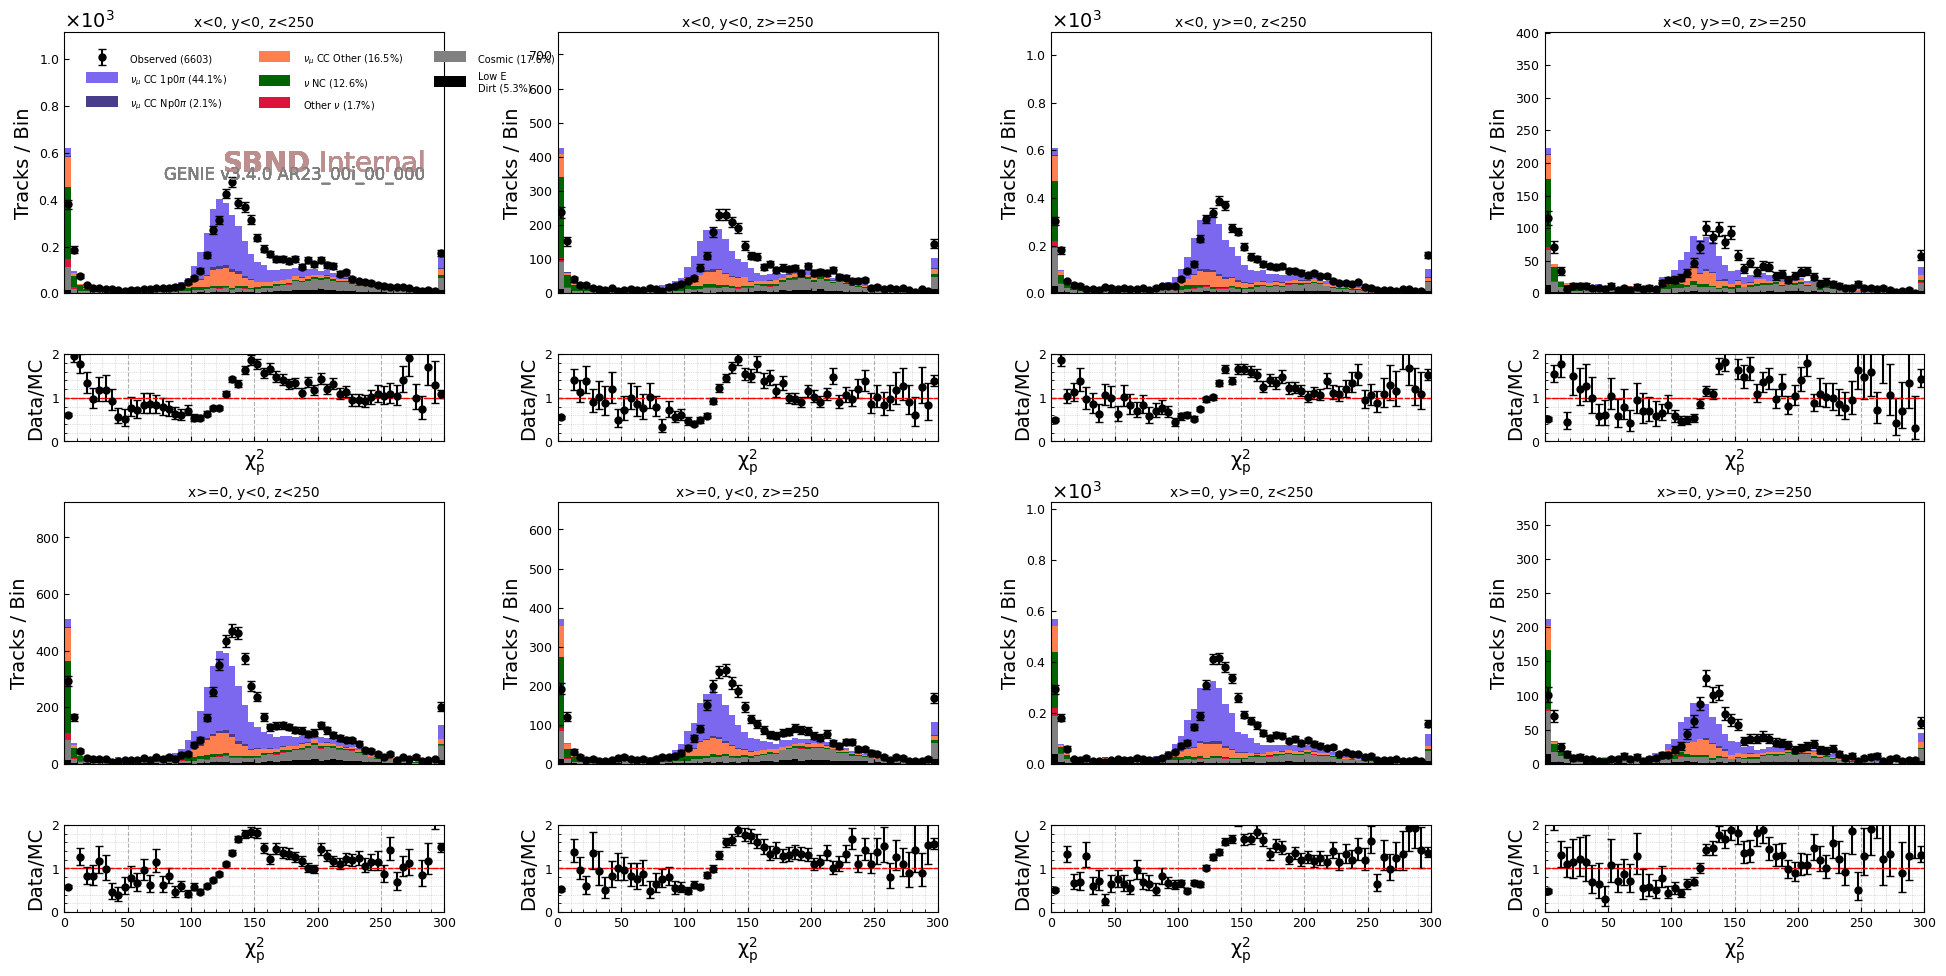

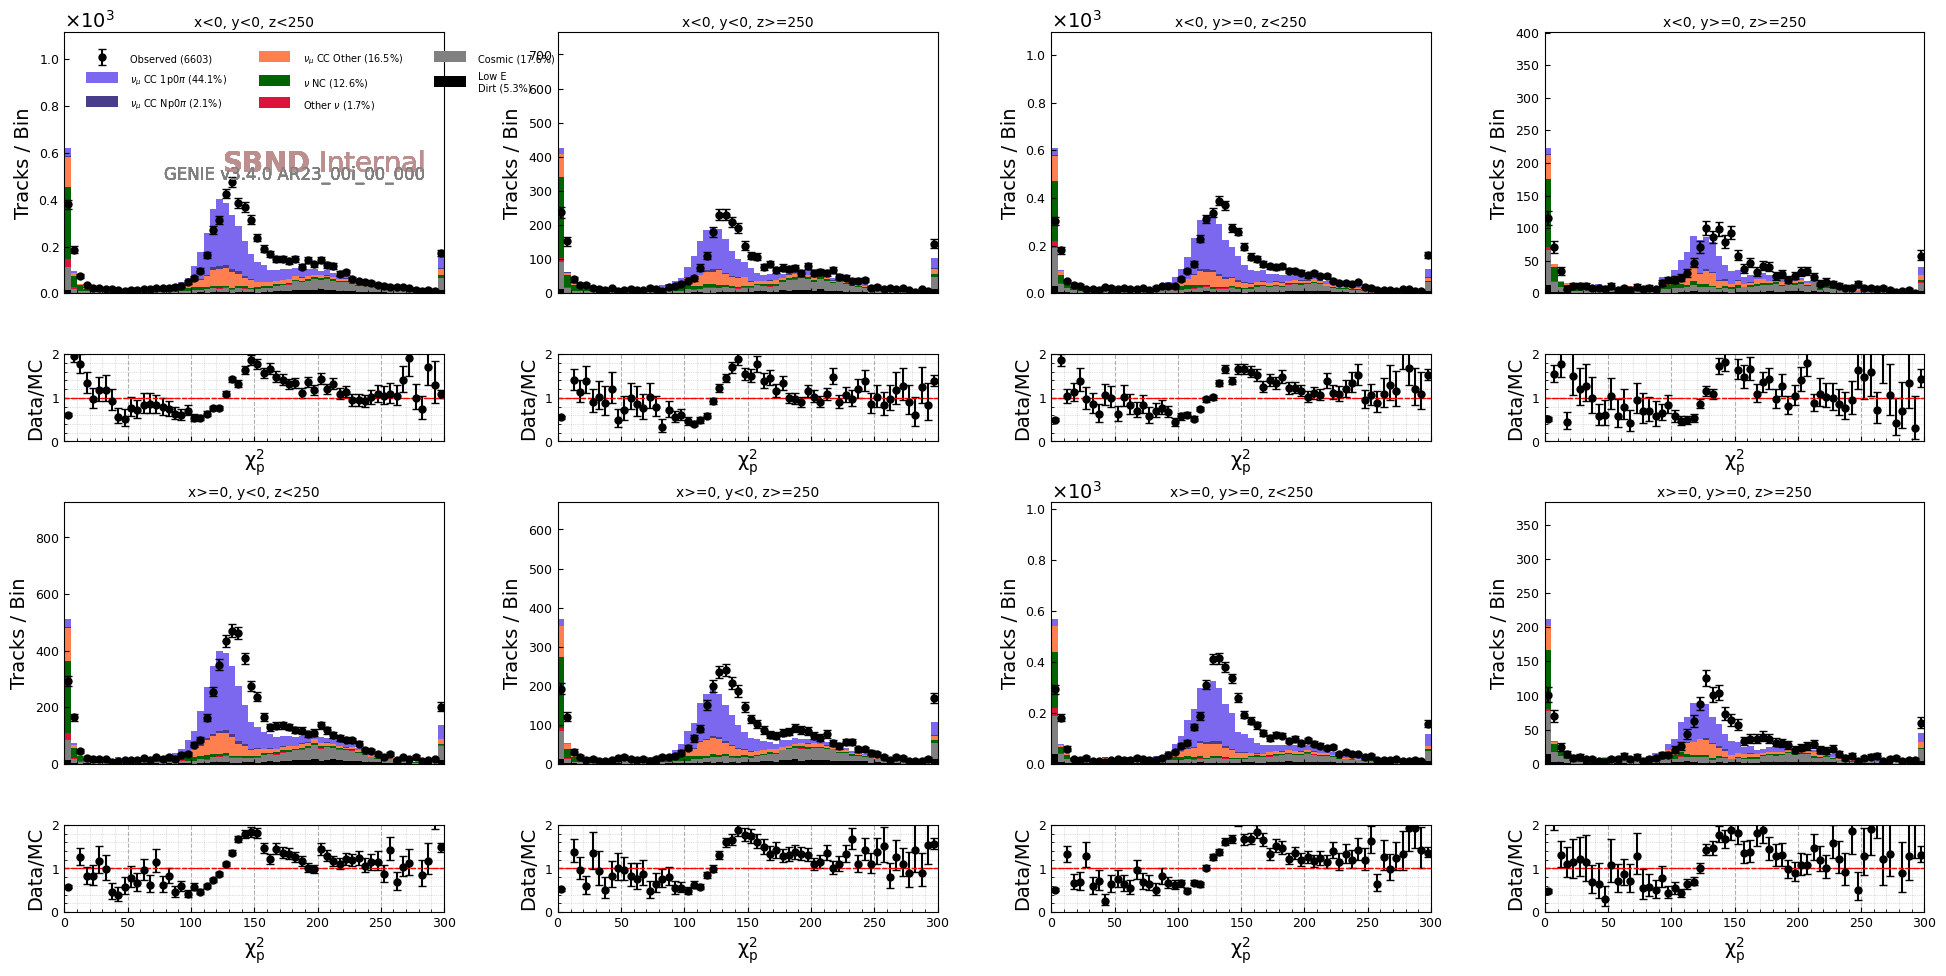

In [ ]:
plot_type = "topology"

var_config = VariableConfig.trk1_chi2_proton()

# for i in range(8):
#     save_name = save_fig_dir + "/2prong-{}_{}-octant-{}.png".format(var_config.var_save_name, plot_type, i)
#     plot_labels = [var_config.var_labels[0], "Tracks / Bin", octant_titles[i]]
#     ret_hist = overlay_hists(plot_type,
#                             mc_df=mc_evt_df_octants[i],
#                             data_df=data_evt_df_octants[i],
#                             intime_df=intime_evt_df_octants[i],
#                             dirt_df=dirt_evt_df_octants[i],
#                             syst=get_wiremod_total_frac_cov(var_config),
#                             load_syst_from_summary=False,
#                             syst_decomp=False,
#                             ratio=True,
#                             ax_ylim_ratio=1.8,
#                             var_config=var_config,
#                             plot_labels=plot_labels,
#                             save_fig=save_fig,
#                             save_name=save_name)

plot_all_octants(
    plot_type,
    var_config,
    mc_evt_df_octants_gen1,
    data_evt_df_octants_gen1,
    intime_evt_df_octants_gen1,
    dirt_octants=dirt_evt_df_octants_gen1,
    suffix="-gen1",
);

overlay_hists: could not load category_syst_summary ("Variable 'trk2_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided
overlay_hists: could not load category_syst_summary ("Variable 'trk2_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_y, vertex_z)")
no syst provided
overlay_hists: could not load category_syst_summary ("Variable 'trk2_chi2_p' not in category summary (have: integrated, muon-dir_x, muon-dir_y, muon-dir_z, muon-p, proton-dir_x, proton-dir_y, proton-dir_z, proton-p, tki-del_Tp, tki-del_Tp_x, tki-del_Tp_y, tki-del_alpha, tki-del_p, tki-del_phi, vertex_x, vertex_

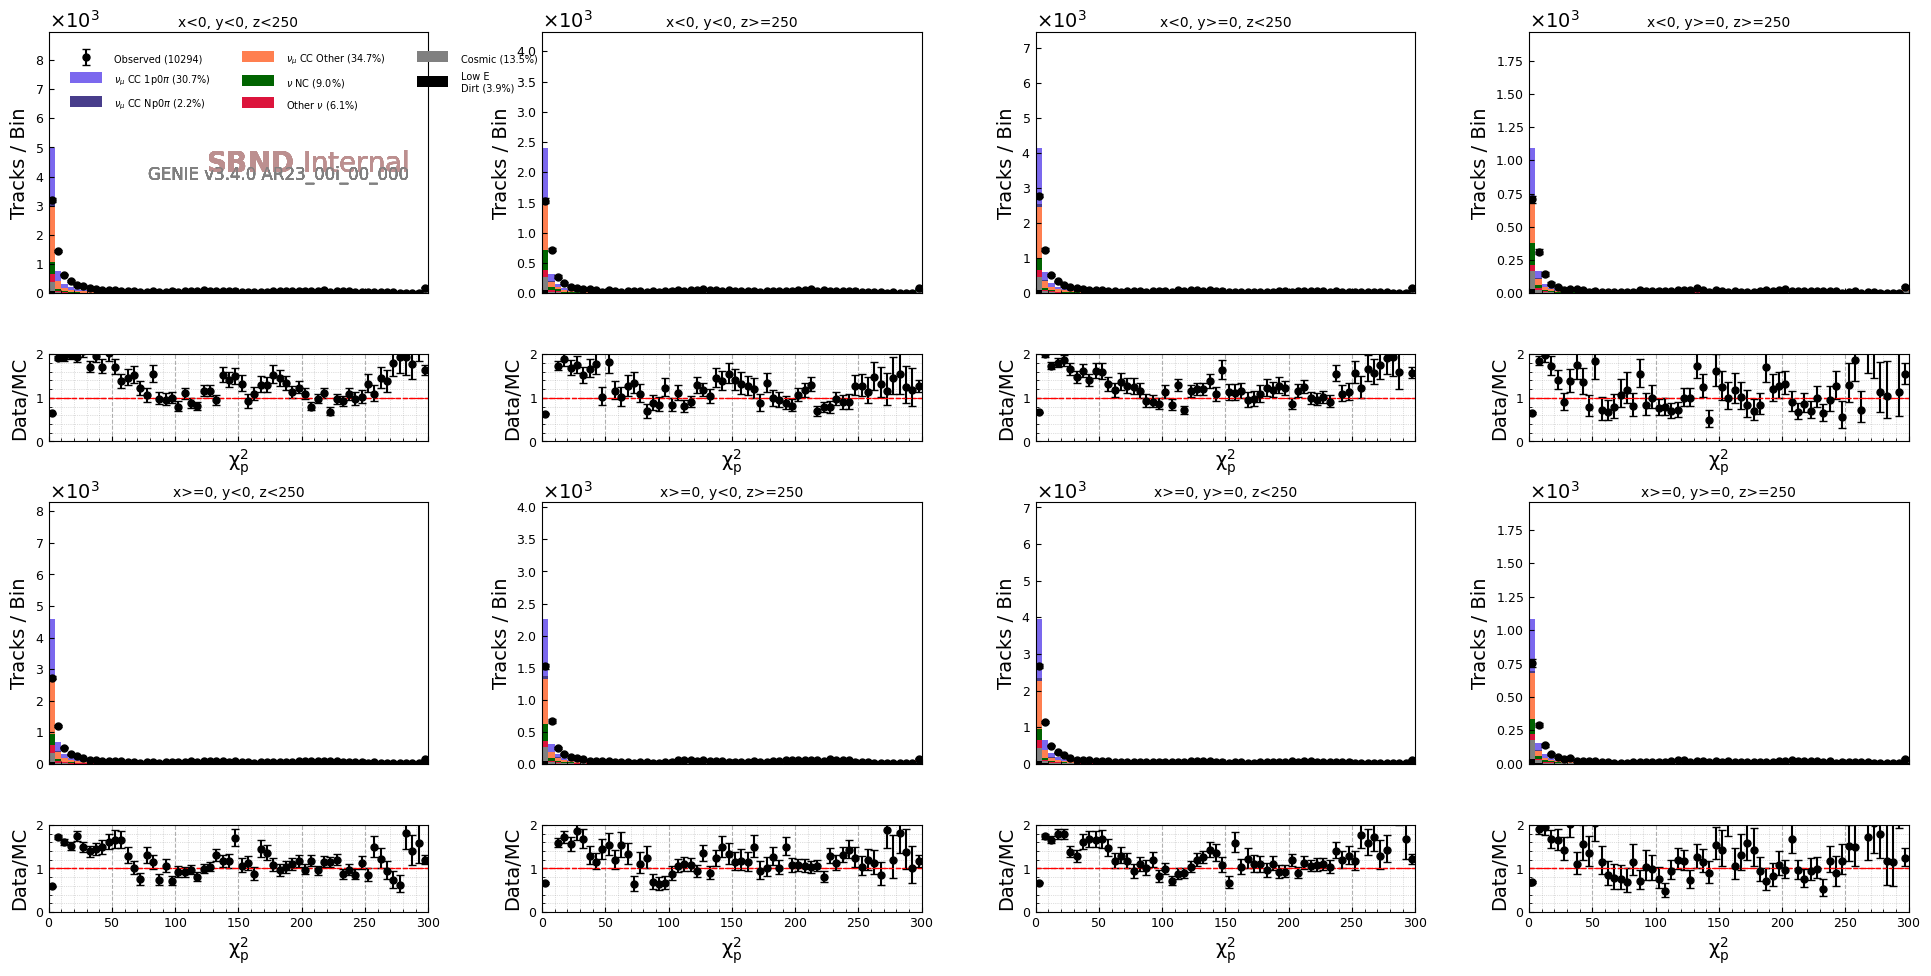

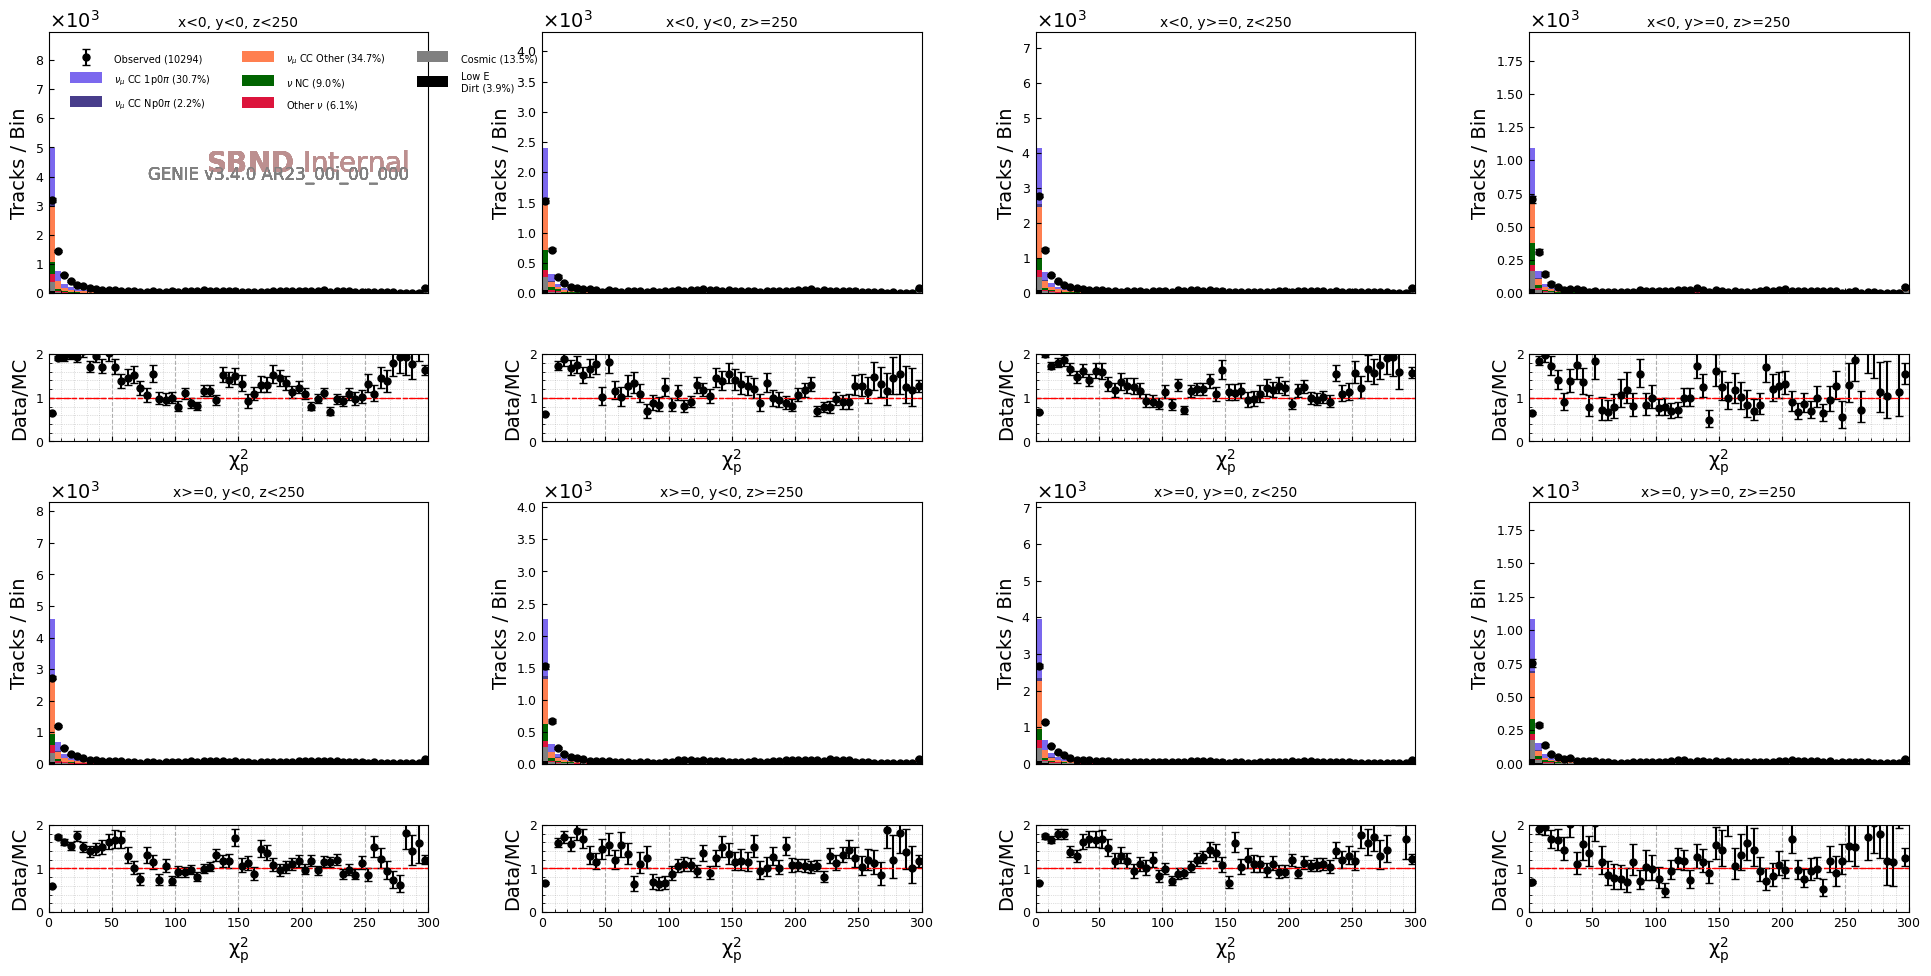

In [106]:
plot_type = "topology"

var_config = VariableConfig.trk2_chi2_proton()

plot_all_octants(
    plot_type,
    var_config,
    mc_evt_df_octants,
    data_evt_df_octants,
    intime_evt_df_octants,
    dirt_octants=dirt_evt_df_octants,
)

In [108]:
# turn off RuntimeWaning
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


(50, 50)
(50, 50)
(50, 50)
(50, 50)
(50, 50)
(50, 50)
(50, 50)
(50, 50)
saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260602/2prong-trk1_len_topology-octants-gen1.png.pdf


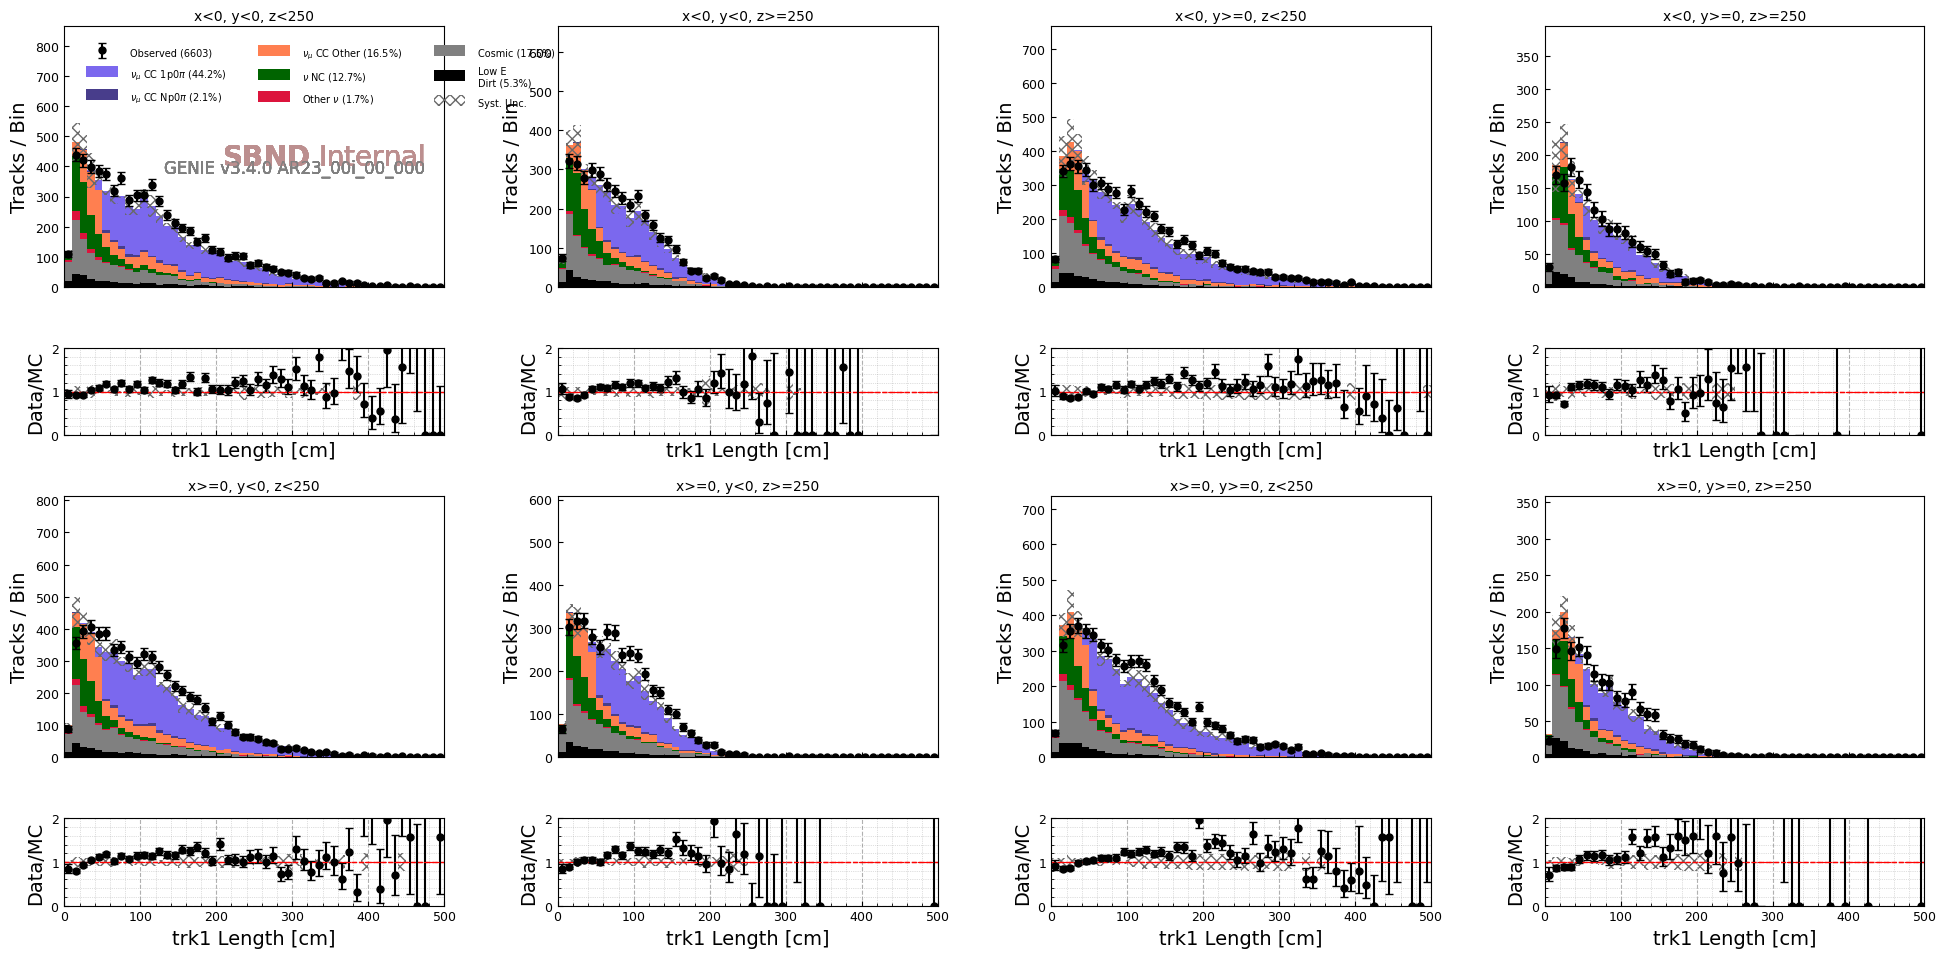

In [109]:
plot_type = "topology"

# var_config = VariableConfig.costh_trk1_trk2()
var_config = VariableConfig.trk1_len()

plot_all_octants(
    plot_type,
    var_config,
    mc_evt_df_octants_gen1,
    data_evt_df_octants_gen1,
    offbeam_evt_df_octants_gen1,
    dirt_octants=dirt_evt_df_octants_gen1,
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260602/2prong-trk1-dir_phi_topology-octants-gen1.png.pdf


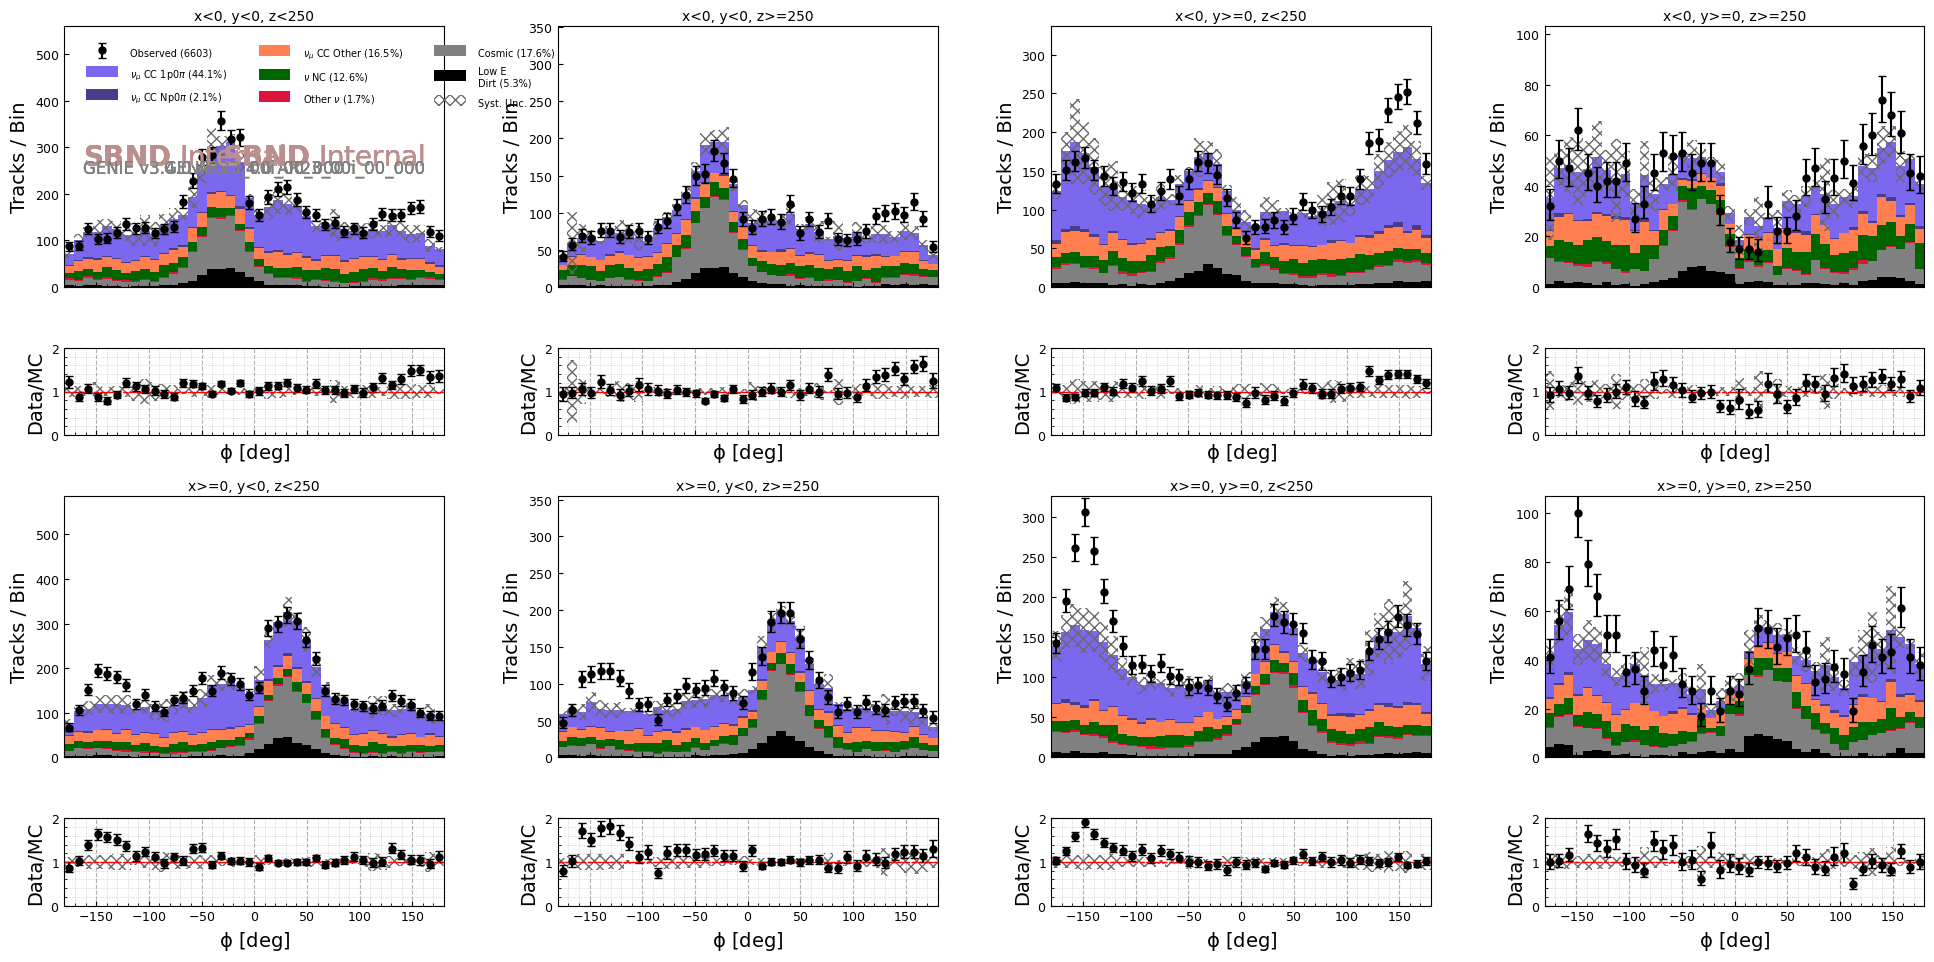

saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260602/2prong-trk2-dir_phi_topology-octants-gen1.png.pdf


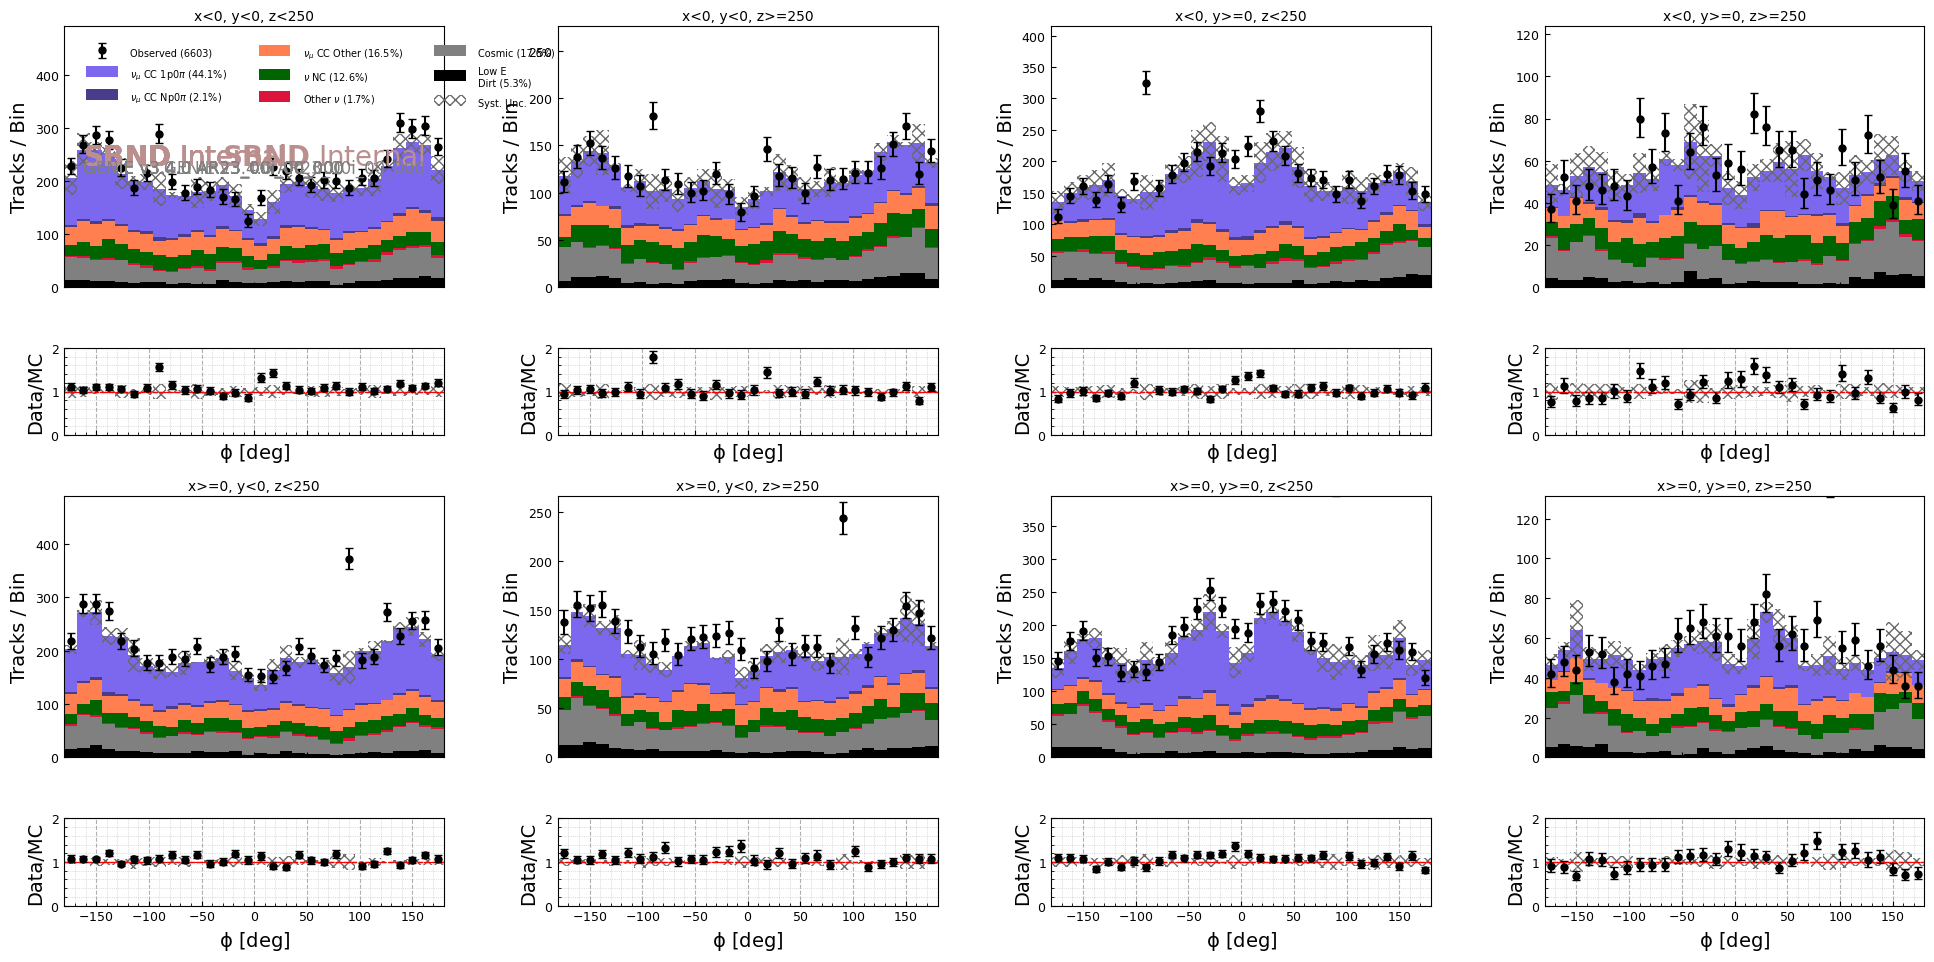

In [112]:
plot_type = "topology"

var_config = VariableConfig.trk1_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    mc_evt_df_octants_gen1,
    data_evt_df_octants_gen1,
    intime_evt_df_octants_gen1,
    dirt_octants=dirt_evt_df_octants_gen1,
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

var_config = VariableConfig.trk2_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    mc_evt_df_octants_gen1,
    data_evt_df_octants_gen1,
    intime_evt_df_octants_gen1,
    dirt_octants=dirt_evt_df_octants_gen1,
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

In [120]:
cut_bin(mc_evt_df_octants_gen1[0])

slc                          \
                              is_clear_cosmic      vertex               
                                                        x           y   
                                                                        
                                                                        
                                                                        
                                                                        
__ntuple entry rec.slc..index                                           
39       2     0                            0  -75.163452 -103.302780   
42       14    0                            0 -123.128548  -85.120567   
43       0     0                            0 -172.205795  -32.325962   
64       5     0                            0 -133.638107  -84.544533   
         8     0                            0 -123.651581 -145.594406   
..                                        ...         ...         ...   
186755   4     2                            0  -48.878834  -92.751945   
186800   4     3                            0 -131.565491 -156.845963   
         10    0                            0  -60.159073 -182.480698   
186807   5     1                            0 -172.434631 -142.625381   
186811   12    0                            0  -47.615650 -134.575089   

                                                                           \
                                          self    tmatch                    
                                        z            eff       pur    idx   
                                                                            
                                                                            
                                                                            
                                                                            
__ntuple entry rec.slc..index                                               
39       2     0               133.923752   71  0.912990  0.965171    1.0   
42       14    0               104.041519   61  0.964368  0.965464    0.0   
43       0     0                44.769554   64  0.931109  0.852590    0.0   
64       5     0               215.722809   77       NaN       NaN -999.0   
         8     0               225.504913   59  0.903836  0.860594    0.0   
..                                    ...  ...       ...       ...    ...   
186755   4     2               228.541870   79  0.579347  0.972162    1.0   
186800   4     3               249.523682   45  0.944432  0.939886    0.0   
         10    0                14.551591   48  0.957380  0.890936    0.0   
186807   5     1               105.060150   56  0.867498  0.923883    1.0   
186811   12    0                99.670273   35  0.921075  0.948433    0.0   

                                                      ...          mc  \
                              producer          nuid  ...   del_alpha   
                                       crlongtrkdiry  ...               
                                                      ...               
                                                      ...               
                                                      ...               
                                                      ...               
__ntuple entry rec.slc..index                         ...               
39       2     0                     0     -0.837296  ...   80.998894   
42       14    0                     0     -0.057846  ...   55.468948   
43       0     0                     0     -0.960277  ...  179.830978   
64       5     0                     0     -0.531991  ...         NaN   
         8     0                     0     -0.256210  ...   75.208817   
..                                 ...           ...  ...         ...   
186755   4     2                     0     -0.288086  ...  167.041306   
186800   4     3                     0      0.187438  ...  164.297363   
         10    0      

saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260602/2prong-trk1-dir_phi_topology-octants-gen1.png.pdf


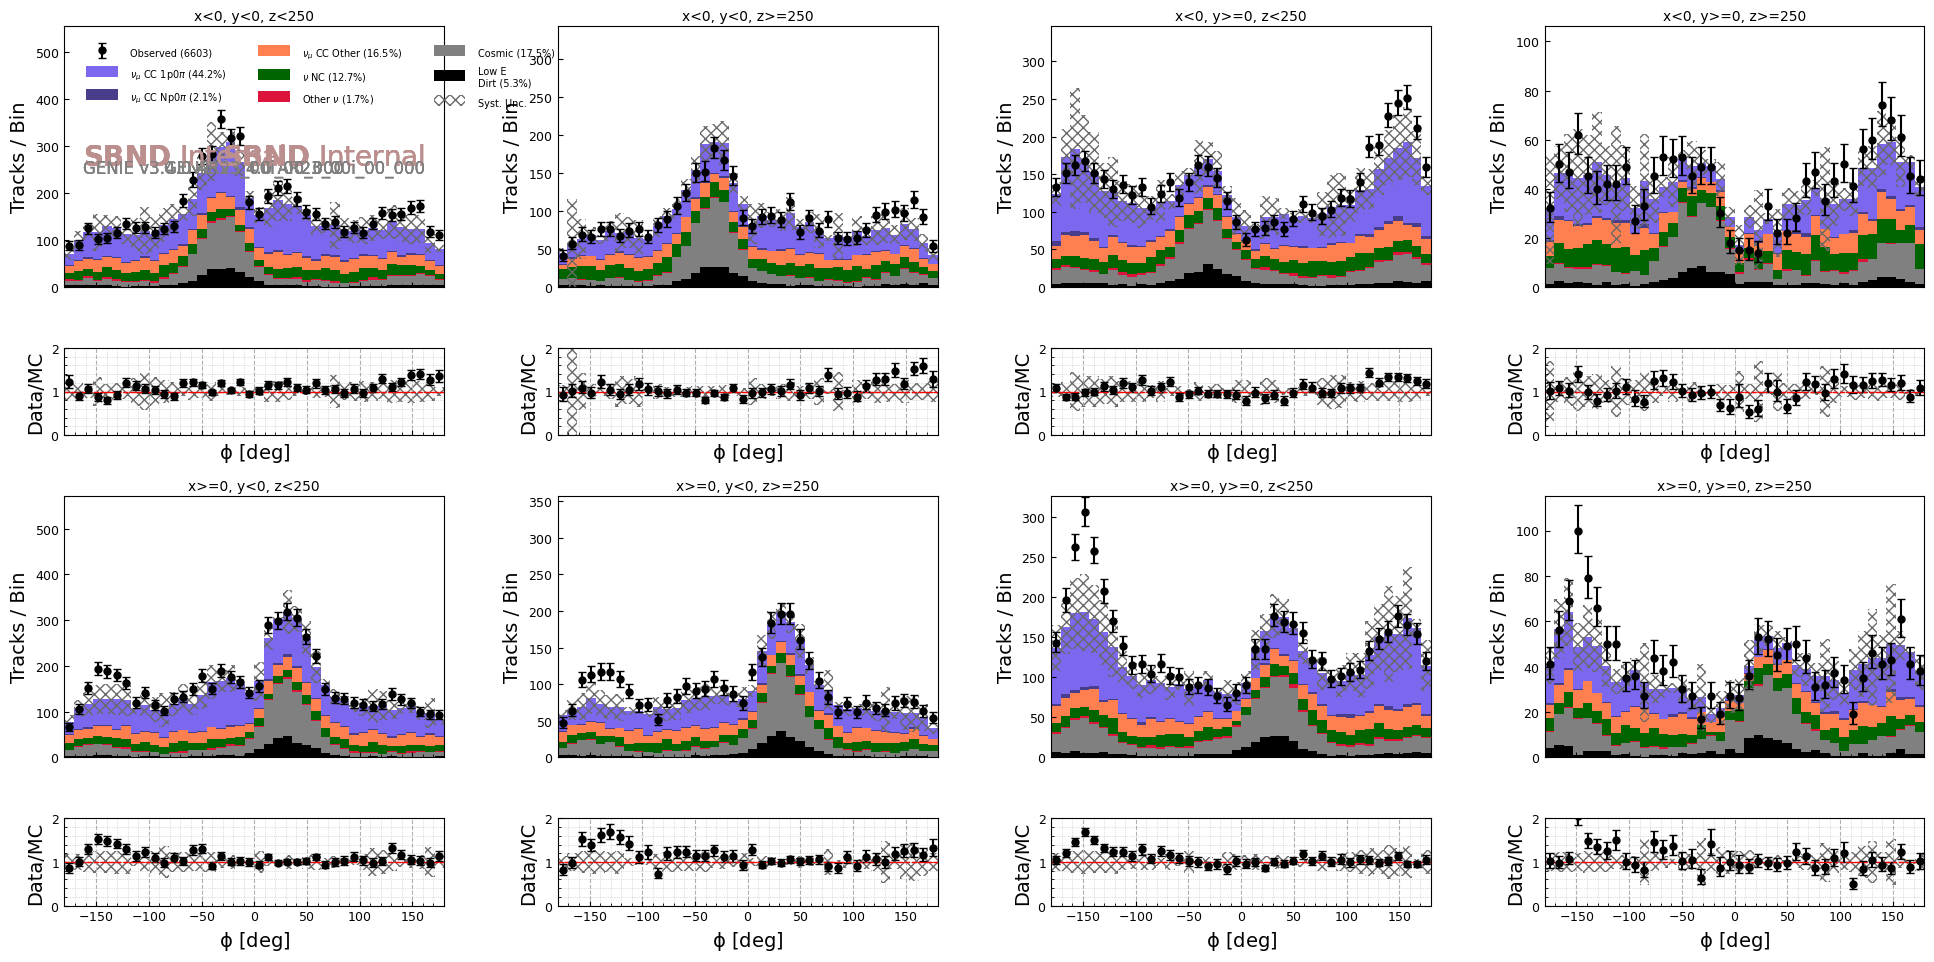

saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260602/2prong-trk2-dir_phi_topology-octants-gen1.png.pdf


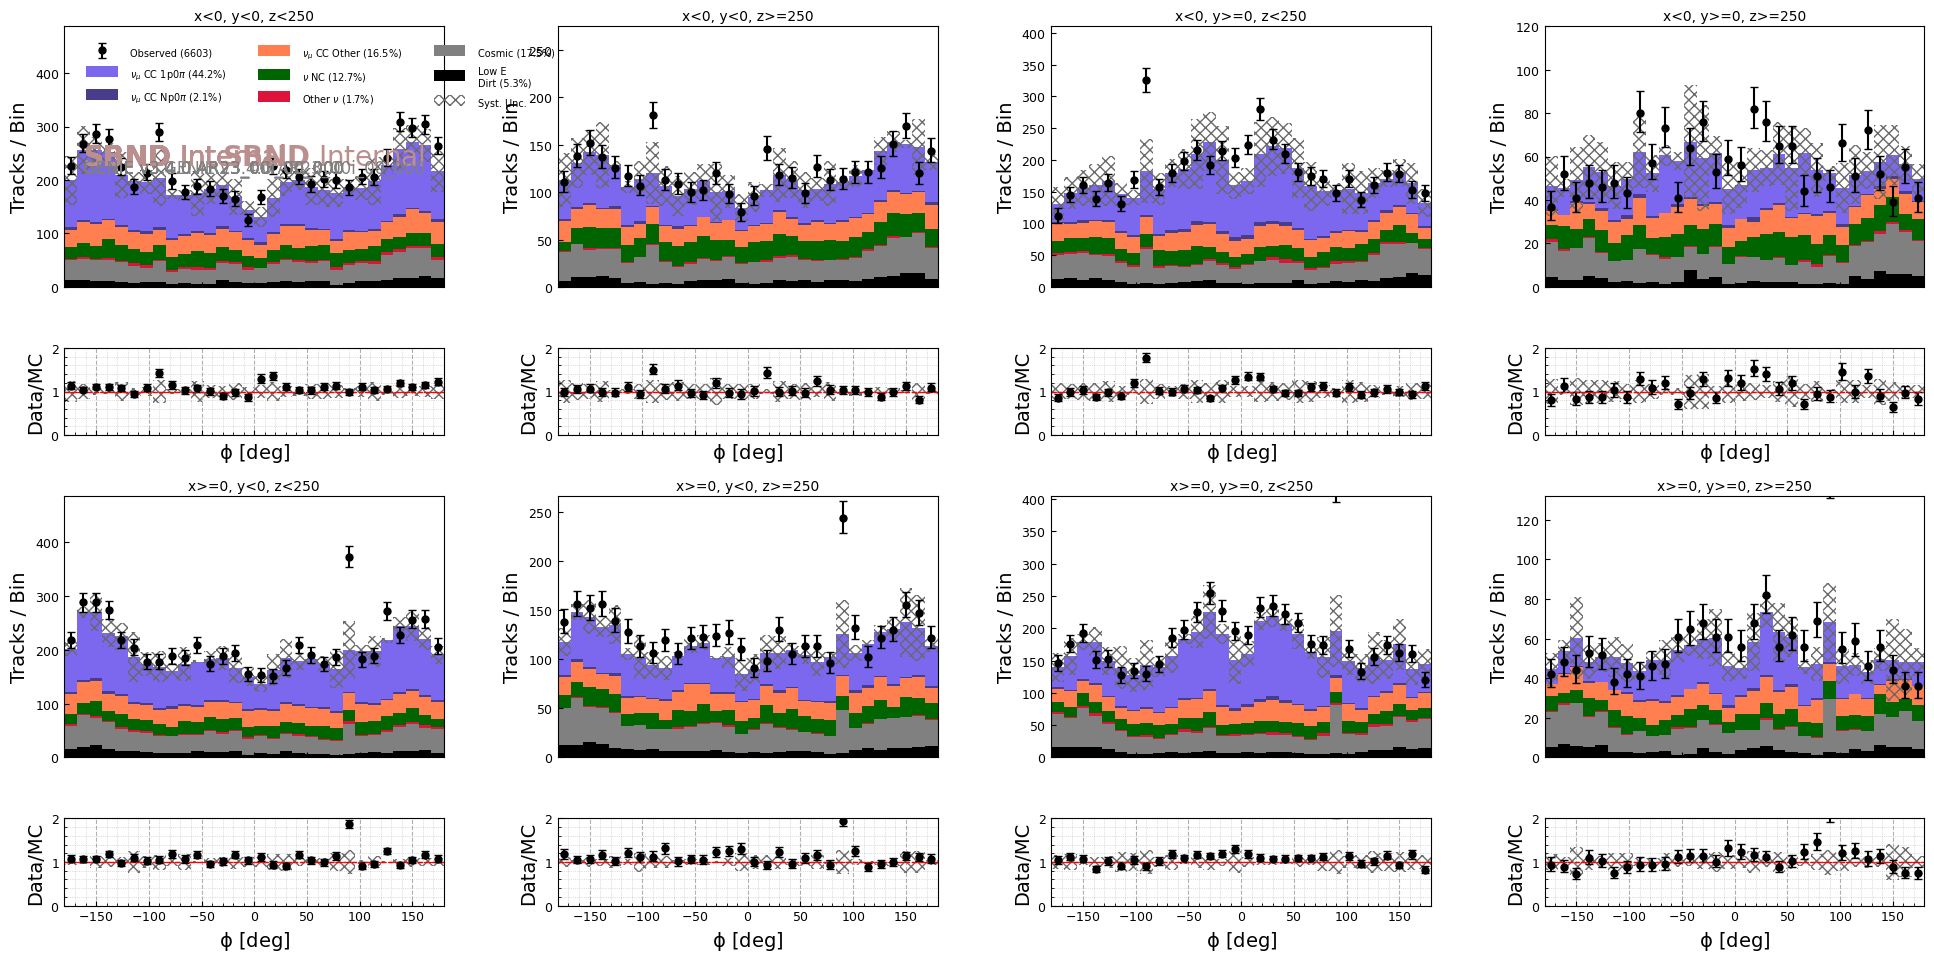

saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260602/2prong-trk1-dir_phi_topology-octants-gen1.png.pdf


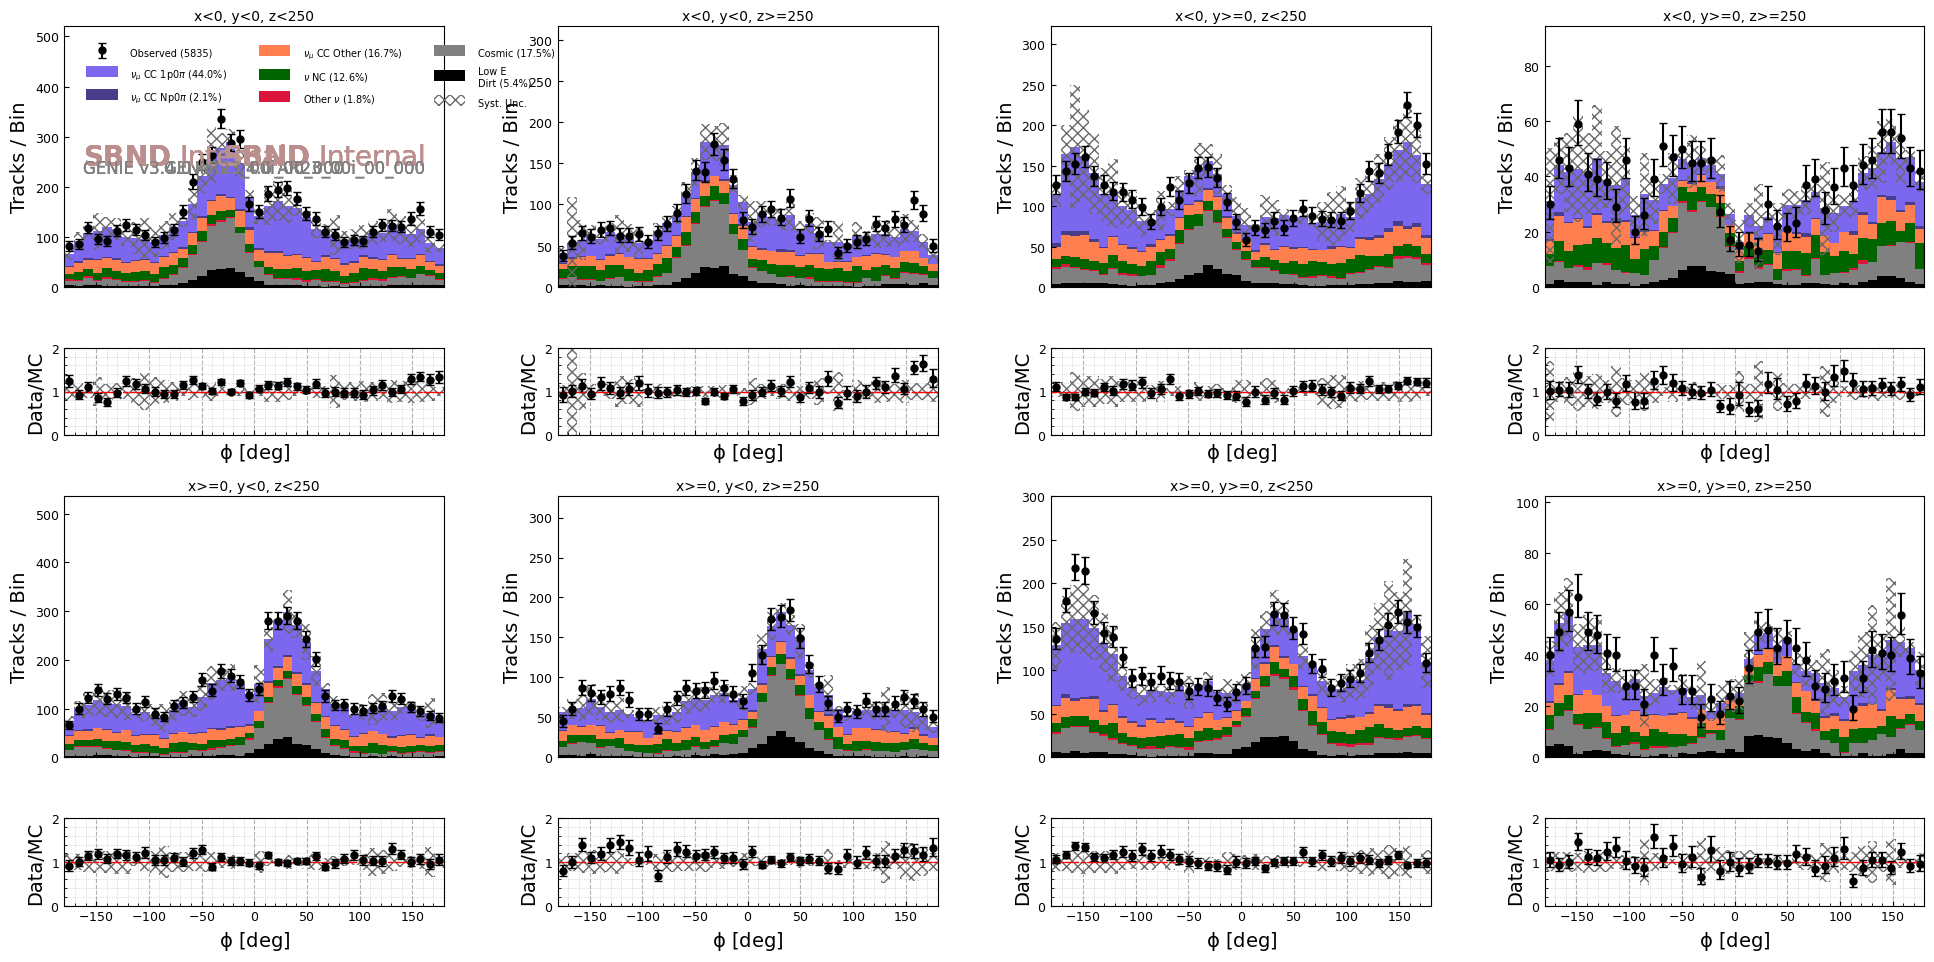

saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260602/2prong-trk2-dir_phi_topology-octants-gen1.png.pdf


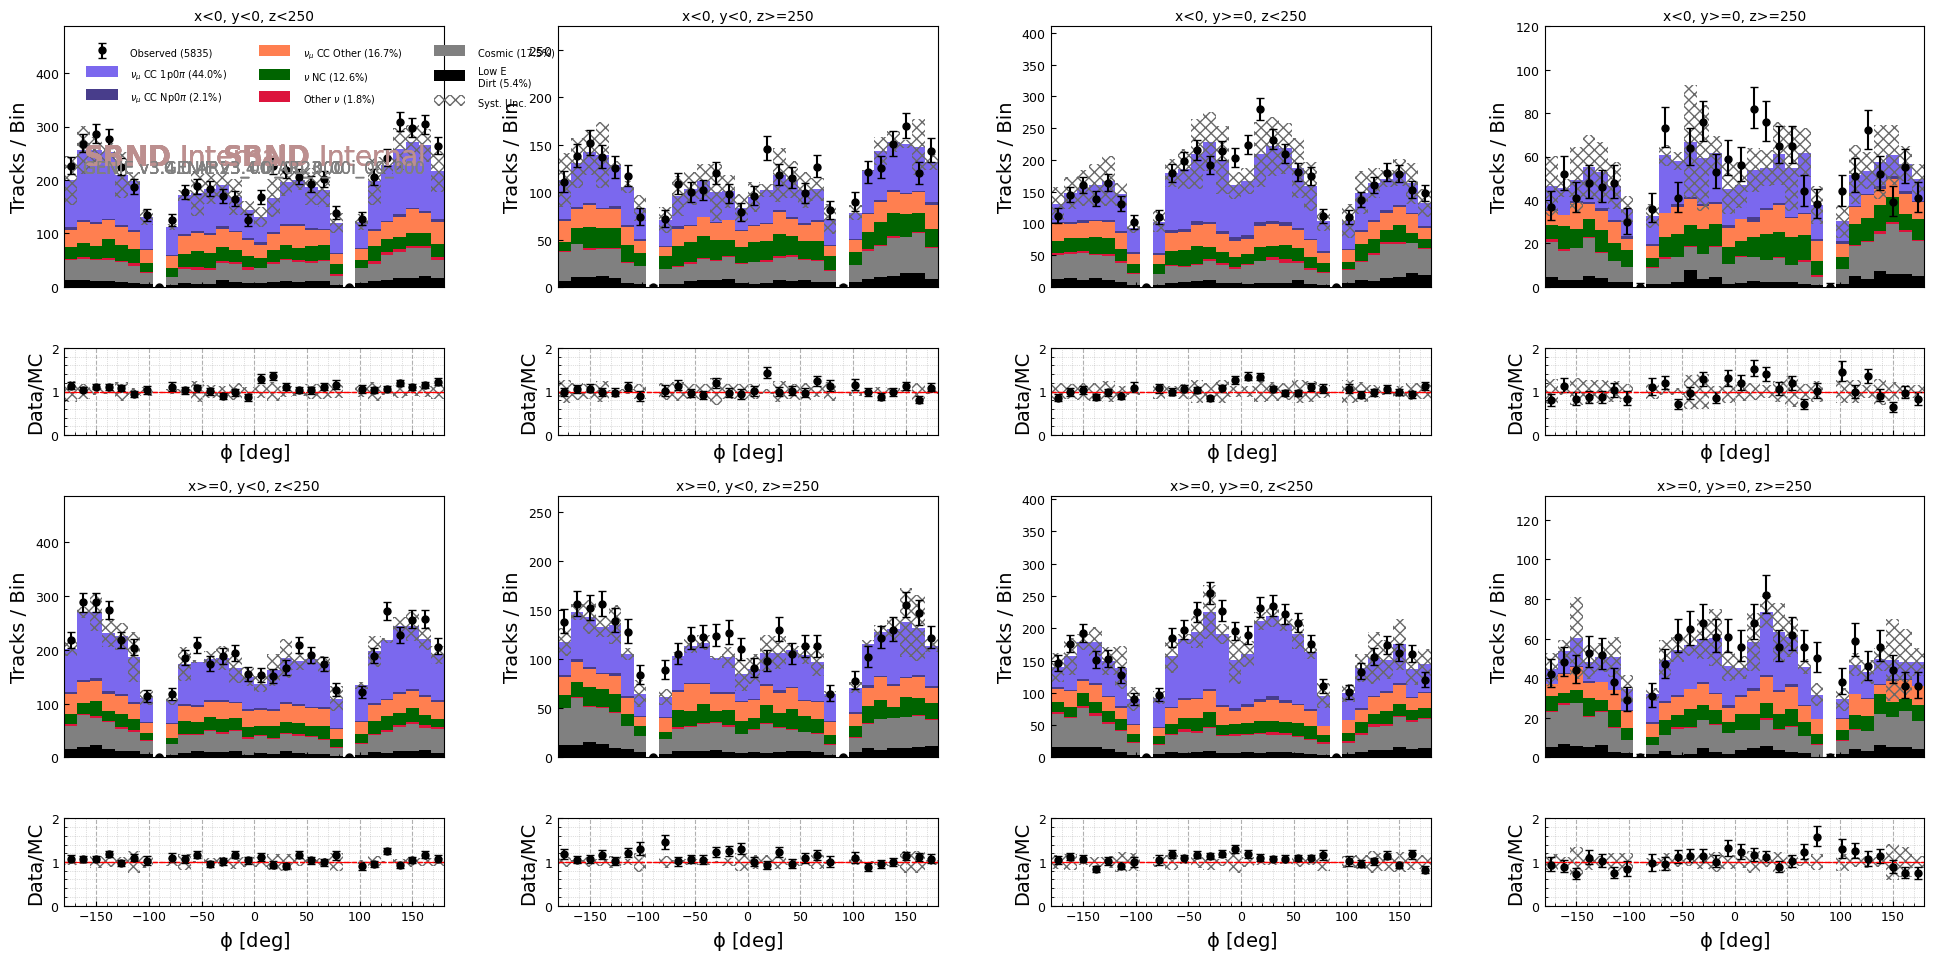

saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260602/2prong-trk1-dir_phi_topology-octants-gen1.png.pdf


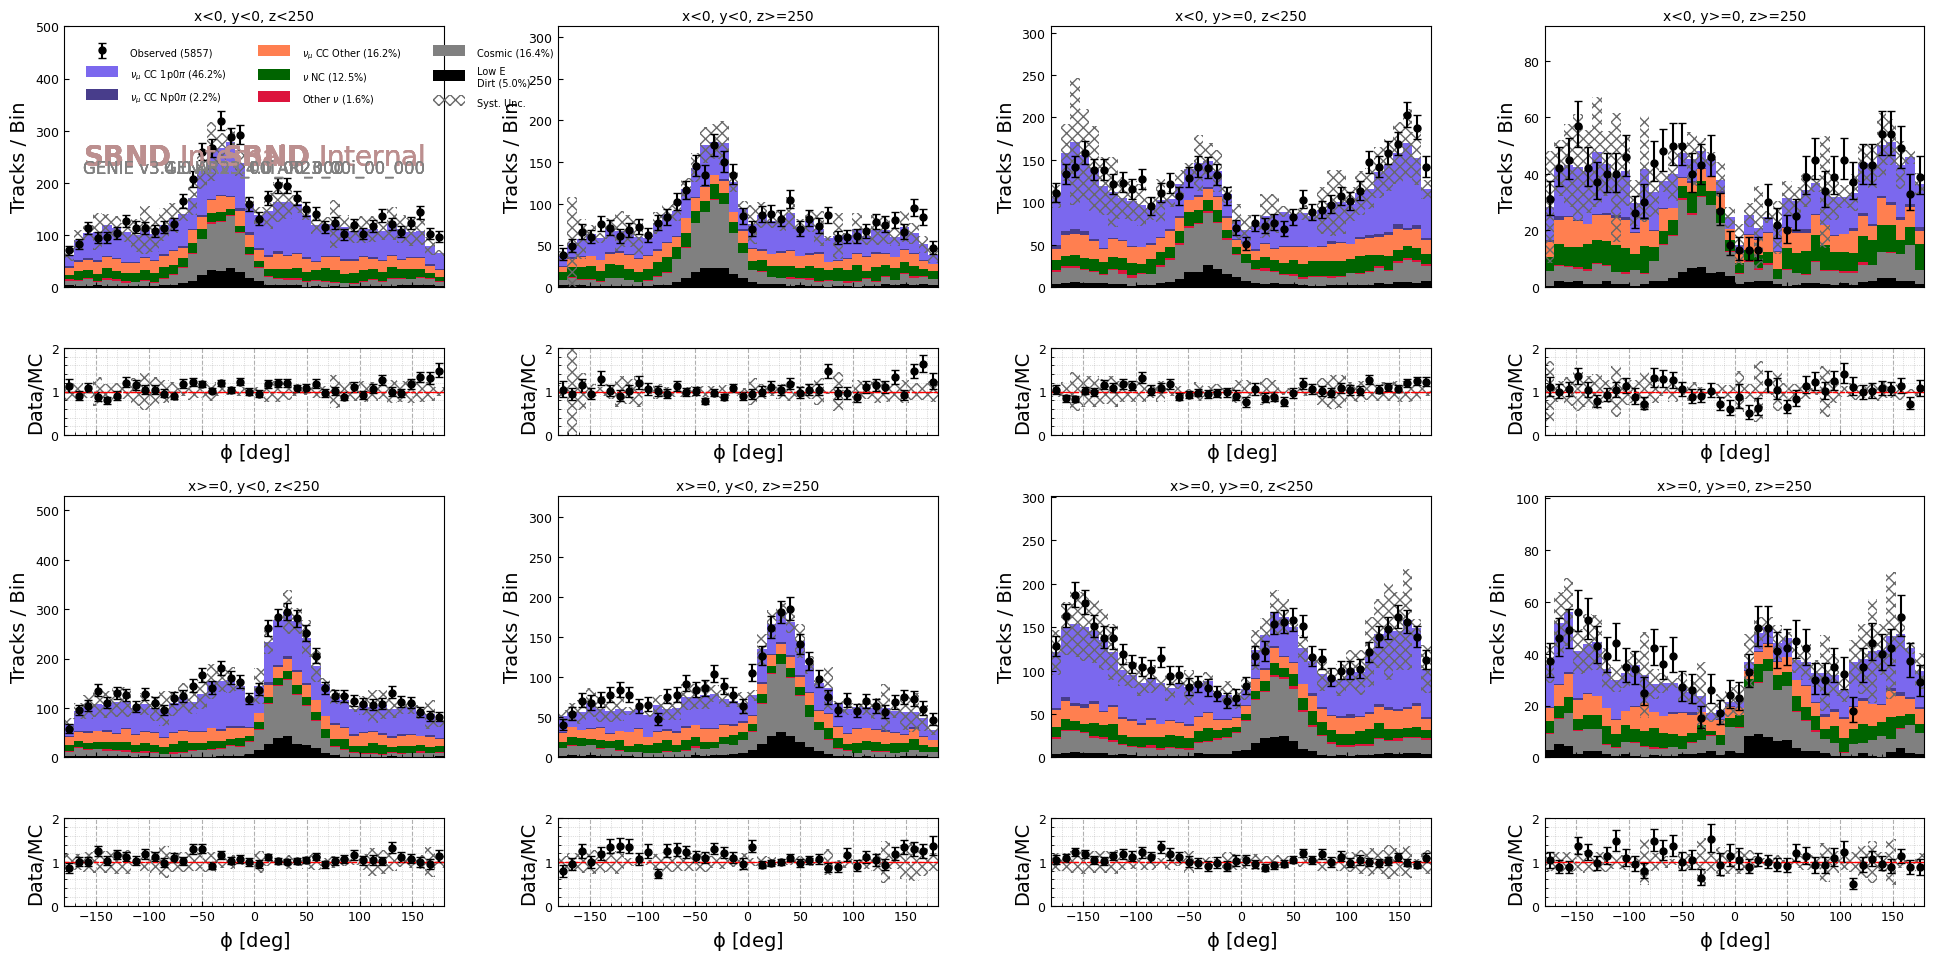

saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260602/2prong-trk2-dir_phi_topology-octants-gen1.png.pdf


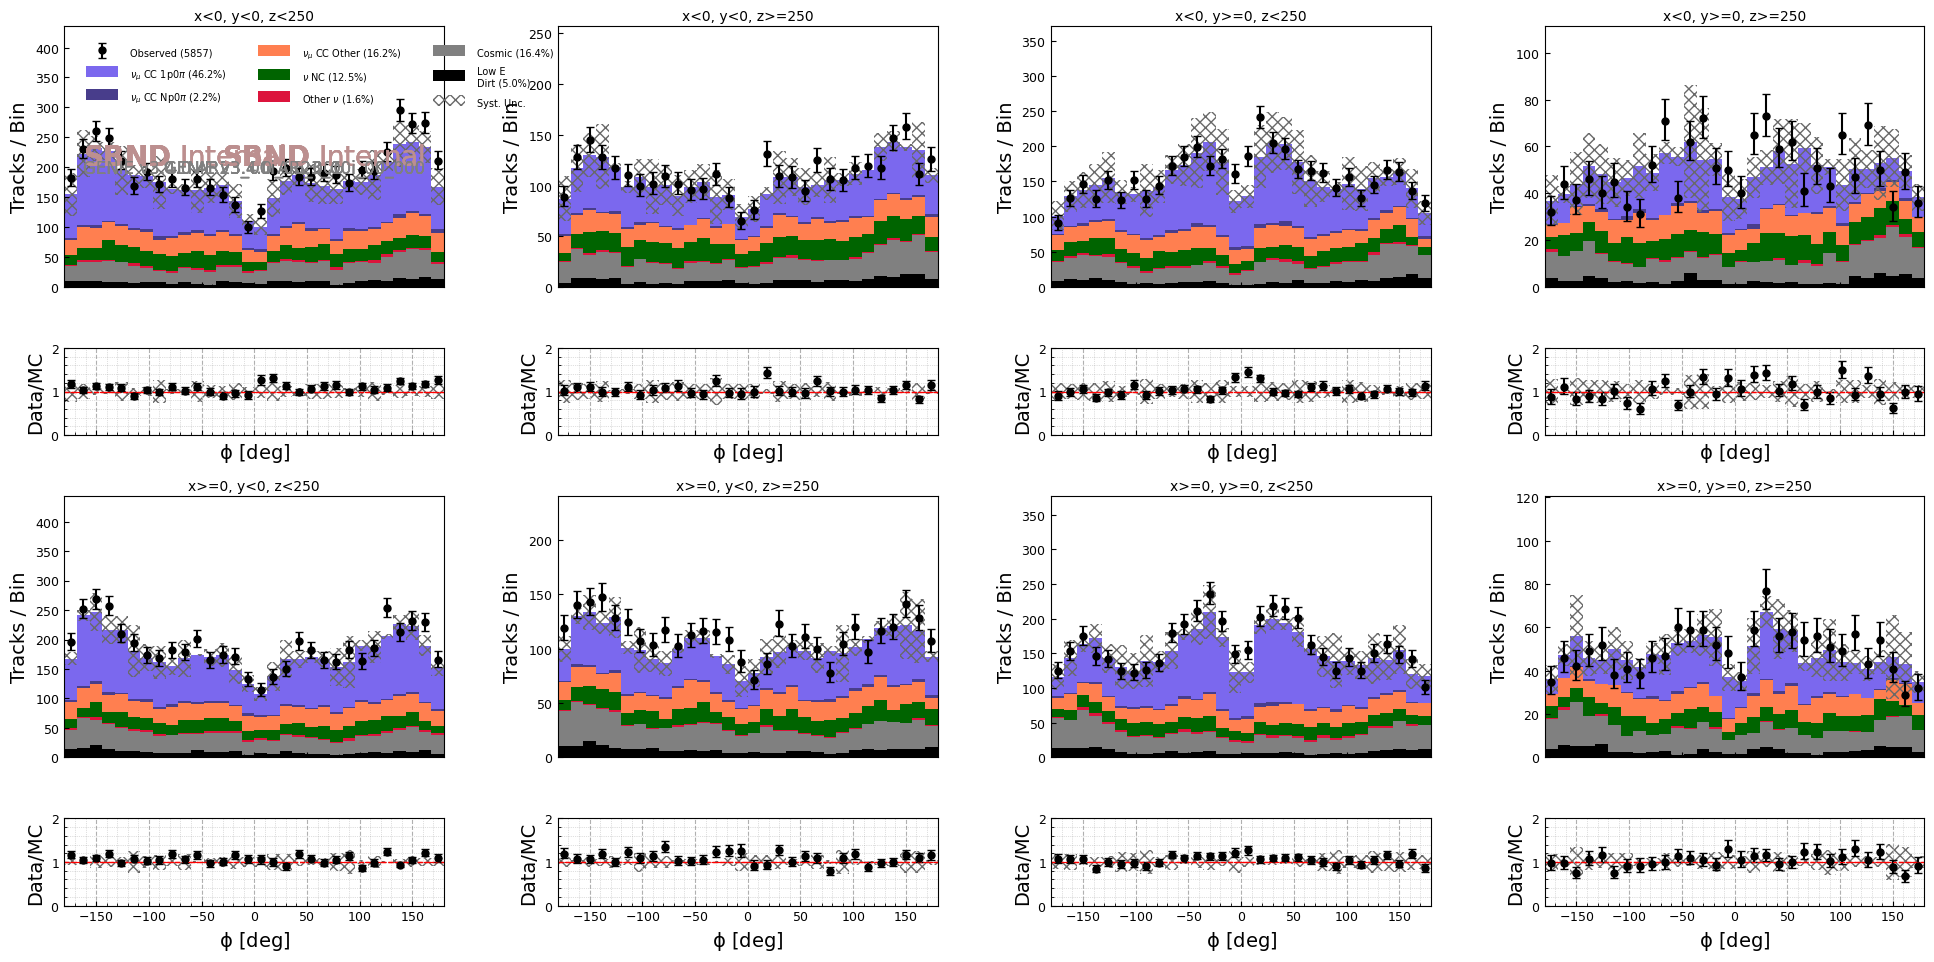

In [146]:
def cut_bin(df):
    return df

plot_type = "topology"

var_config = VariableConfig.trk1_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

var_config = VariableConfig.trk2_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

def cut_bin(df):
    this_var_config = VariableConfig.trk2_direction_phi()
    return df[(np.abs(np.abs(df[this_var_config.var_evt_reco_col]) - 90) > 10)] # & (np.abs(np.abs(df[this_var_config.var_evt_reco_col]) - 0) > 10)]

plot_type = "topology"

var_config = VariableConfig.trk1_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

var_config = VariableConfig.trk2_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);


def cut_bin(df):
    this_var_config = VariableConfig.trk2_chi2_mu()
    return df[(df[this_var_config.var_evt_reco_col] > 0)]

plot_type = "topology"

var_config = VariableConfig.trk1_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

var_config = VariableConfig.trk2_direction_phi()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260602/2prong-trk2_chi2_mu_topology-octants-gen1.png.pdf


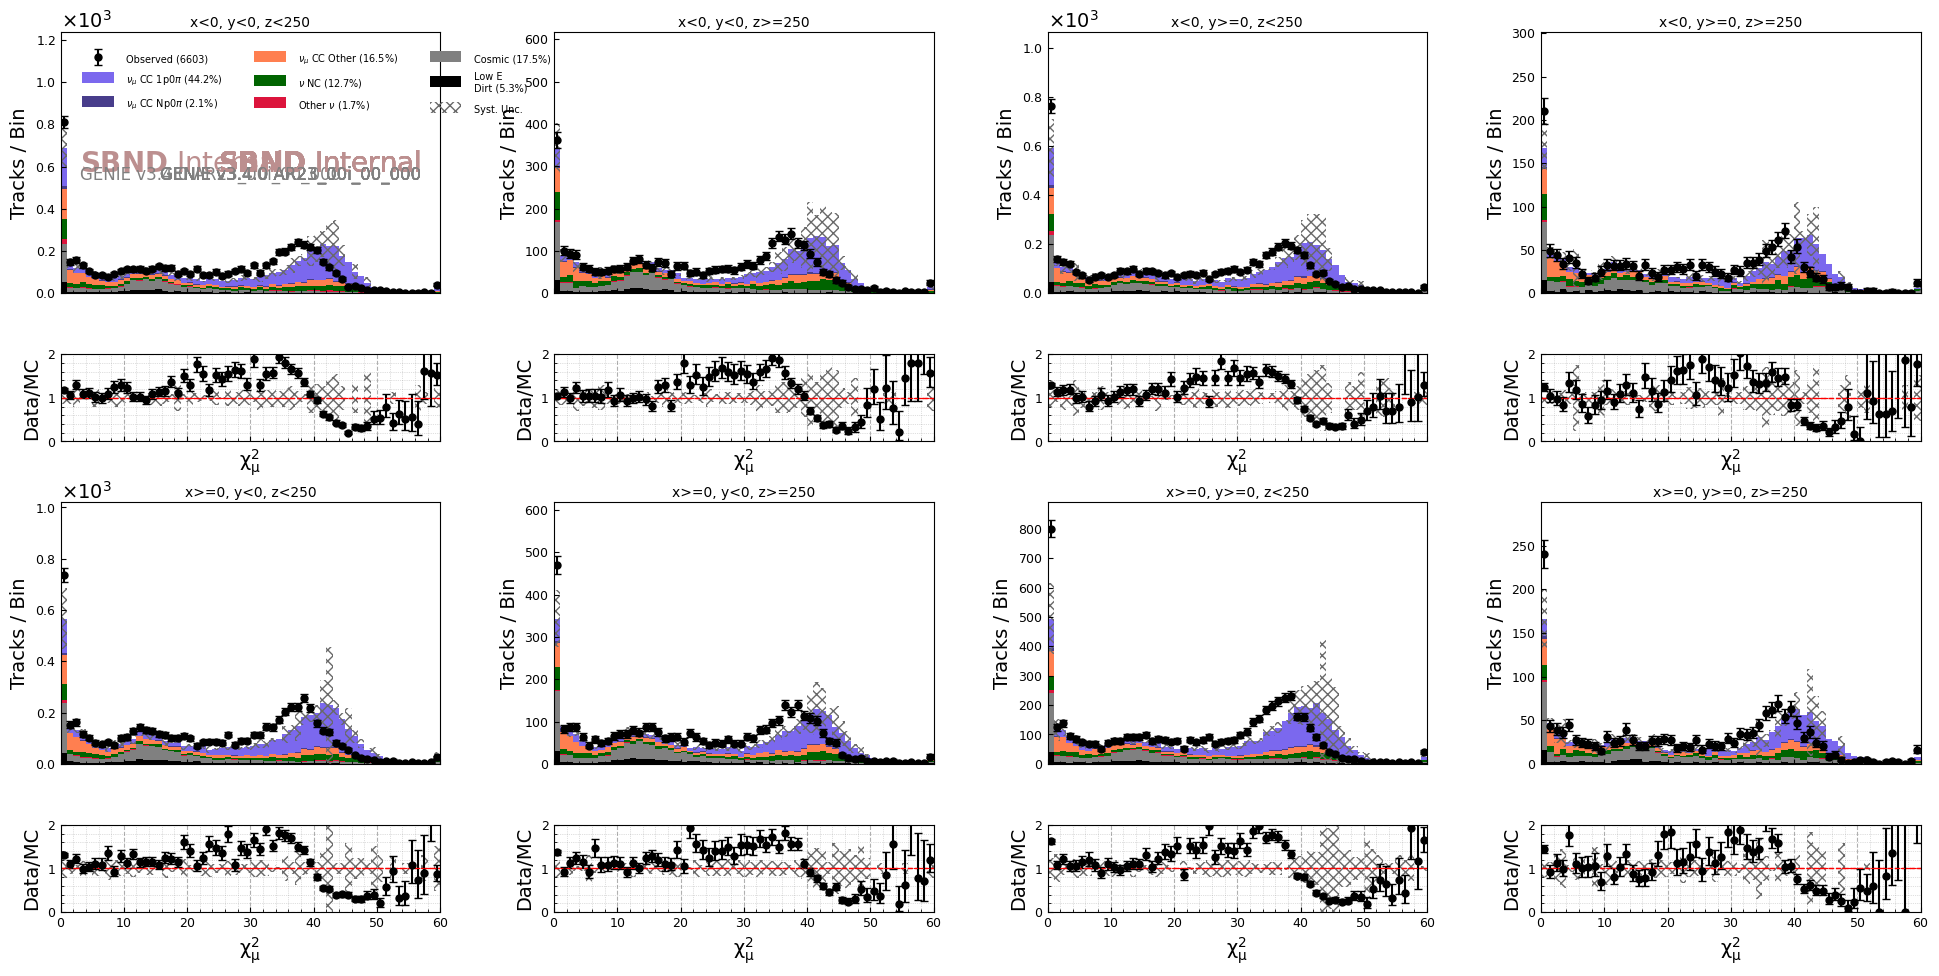

saved /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_chi2_comparison_20260602/2prong-trk2_chi2_mu_topology-octants-gen1.png.pdf


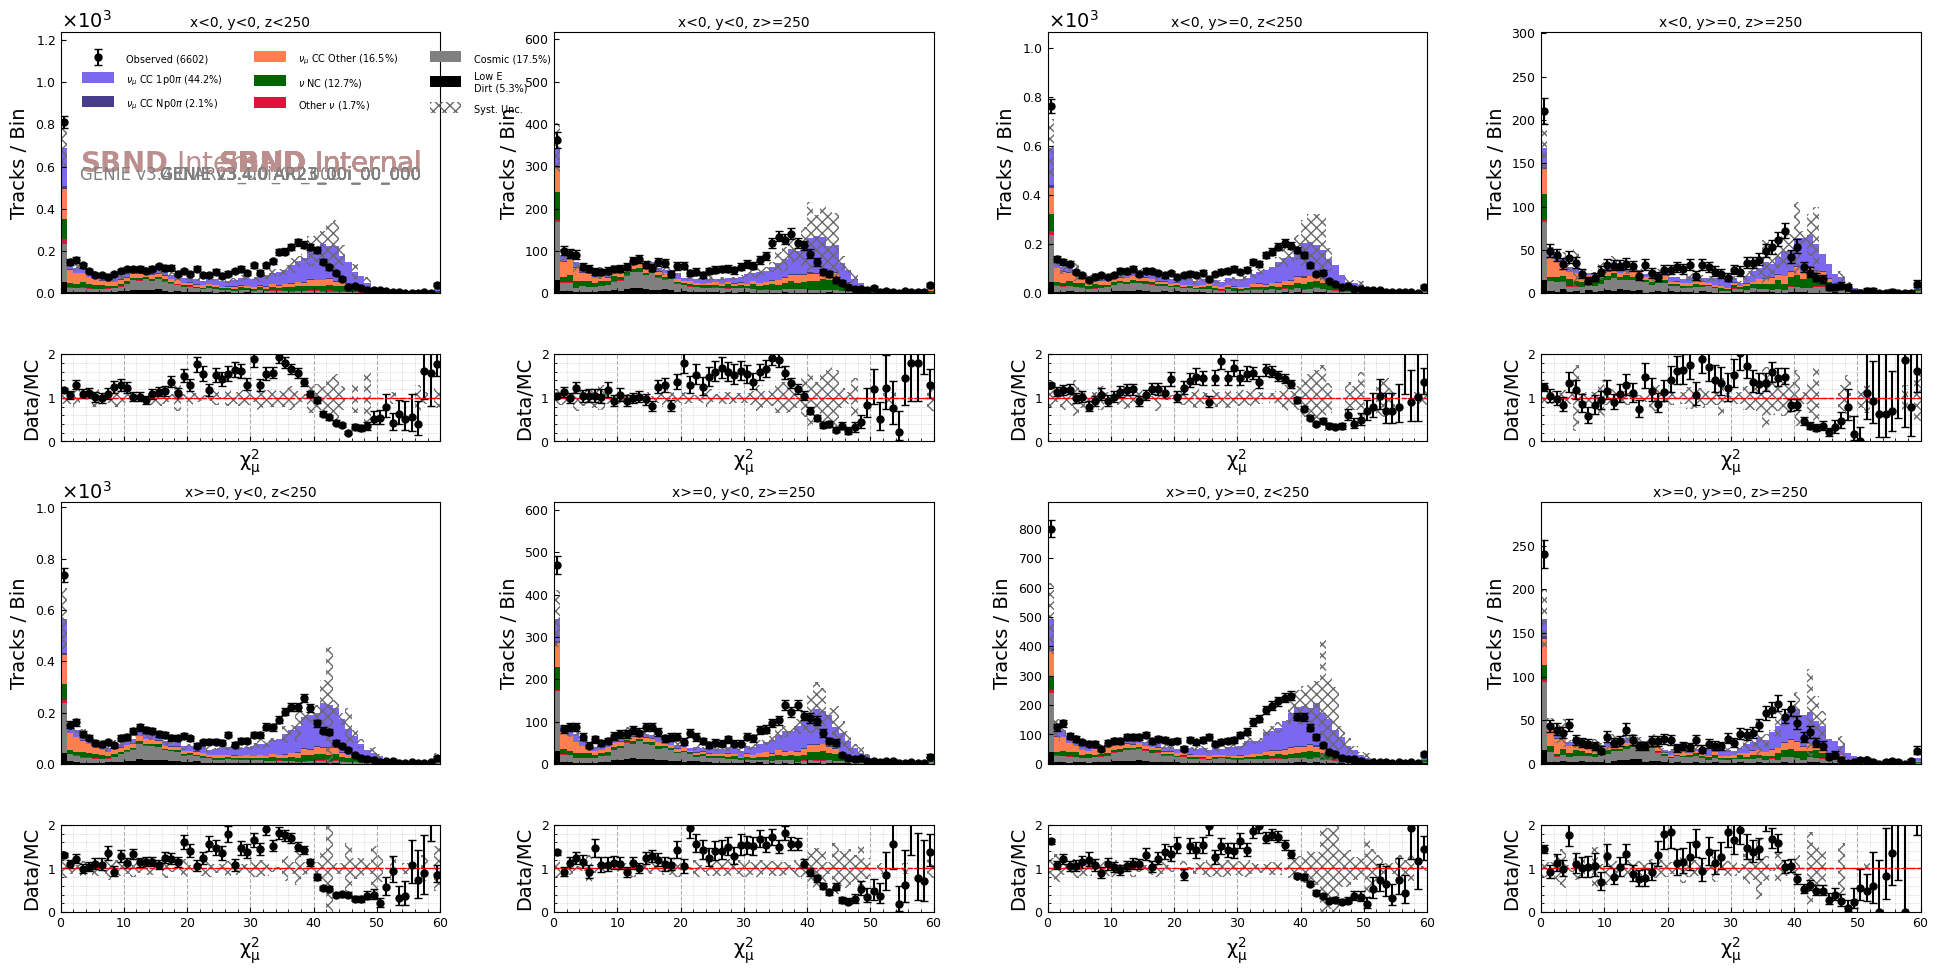

In [133]:
def cut_bin(df):
    return df

plot_type = "topology"

# var_config = VariableConfig.trk1_chi2_mu()
# plot_all_octants(
#     plot_type,
#     var_config,
#     [cut_bin(df) for df in mc_evt_df_octants_gen1],
#     [cut_bin(df) for df in data_evt_df_octants_gen1],
#     [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
#     dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
#     suffix="-gen1",
#     syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
# );

var_config = VariableConfig.trk2_chi2_mu()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

def cut_bin(df):
    this_var_config = VariableConfig.trk2_chi2_mu()
    return df[(np.abs(np.abs(df[this_var_config.var_evt_reco_col]) - 90) > 10)] # & (np.abs(np.abs(df[this_var_config.var_evt_reco_col]) - 0) > 10)]

plot_type = "topology"

# var_config = VariableConfig.trk1_chi2_mu()
# plot_all_octants(
#     plot_type,
#     var_config,
#     [cut_bin(df) for df in mc_evt_df_octants_gen1],
#     [cut_bin(df) for df in data_evt_df_octants_gen1],
#     [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
#     dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
#     suffix="-gen1",
#     syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
# );

var_config = VariableConfig.trk2_chi2_mu()
plot_all_octants(
    plot_type,
    var_config,
    [cut_bin(df) for df in mc_evt_df_octants_gen1],
    [cut_bin(df) for df in data_evt_df_octants_gen1],
    [cut_bin(df) for df in offbeam_evt_df_octants_gen1],
    dirt_octants=[cut_bin(df) for df in dirt_evt_df_octants_gen1],
    suffix="-gen1",
    syst_per_octant=lambda i: cosmic_frac_cov_octant_gen1(i, var_config),
);

In [145]:
cut_dfs = [cut_bin(df) for df in mc_evt_df_octants_gen1]
for oidx in range(8):
    print(oidx, (data_evt_df_octants_gen1[oidx].trk2.pfp.trk.chi2pid.I2.chi2_muon == 0).sum() / len(data_evt_df_octants_gen1[oidx]))
    print(oidx, (cut_dfs[oidx].trk2.pfp.trk.chi2pid.I2.chi2_muon == 0).sum() / len(cut_dfs[oidx]))
    print( " ------  ")


0 0.11297894896259277
0 0.09429192875198401
 ------  
1 0.09098338327431217
1 0.07242483727657816
 ------  
2 0.13128901946382665
2 0.09061714604858978
 ------  
3 0.11316259678379988
3 0.07192162101981742
 ------  
4 0.10636952742215901
4 0.07324742585856095
 ------  
5 0.11632171862719413
5 0.0744272717307903
 ------  
6 0.135227477072469
6 0.06888068880688807
 ------  
7 0.13467217956290609
7 0.07137809187279152
 ------  


In [ ]:
plot_type = "topology"

var_config = VariableConfig.trk2_direction_phi()

plot_all_octants(
    plot_type,
    var_config,
    mc_evt_df_octants,
    data_evt_df_octants,
    intime_evt_df_octants,
    dirt_octants=dirt_evt_df_octants,
)

In [ ]:
save_fig_dir

In [ ]:


# for i in range(8):
#     save_name = save_fig_dir + "/2prong-{}_{}-octant-{}.png".format(var_config.var_save_name, plot_type, i)
#     plot_labels = [var_config.var_labels[0], "Tracks / Bin", octant_titles[i]]
#     ret_hist = overlay_hists(plot_type,
#                             mc_df=mc_evt_df_octants[i],
#                             data_df=data_evt_df_octants[i],
#                             intime_df=intime_evt_df_octants[i],
#                             dirt_df=dirt_evt_df_octants[i],
#                             syst=get_wiremod_total_frac_cov(var_config),
#                             load_syst_from_summary=False,
#                             syst_decomp=False,
#                             ratio=True,
#                             ax_ylim_ratio=1.8,
#                             var_config=var_config,
#                             plot_labels=plot_labels,
#                             save_fig=save_fig,
#                             save_name=save_name)